<a href="https://colab.research.google.com/github/DavidGomezAgudelo/Proyecto-Modelos-II/blob/main/Proyecto_Modelos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto Modelos II

## 1. Instalación de Dependencias y Carga de Librerías

In [ ]:
!pip install scikit-learn==1.7.2  --no-cache-dir


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 51.6 MB/s eta 0:00:00
  Attempting uninstall: scikit-learn
    Found existing installation: scikit-learn 1.6.1
    Uninstalling scikit-learn-1.6.1:
      Successfully uninstalled scikit-learn-1.6.1


In [ ]:
# Importaciones generales
import os
import zipfile
import shutil
import urllib.request
import warnings
warnings.filterwarnings('ignore')

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

In [ ]:
# Importaciones de sklearn y modelos
from sklearn.model_selection import (
    train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score, roc_auc_score,
    mean_absolute_error, mean_squared_error
)

# Modelos a utilizar (5 requeridos)
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Modelos adicionales
#from catboost import CatBoostClassifier

print("Todas las librerías cargadas correctamente")

Todas las librerías cargadas correctamente


## 2. Descargar y Cargar el Dataset

### Descarga

In [ ]:
colab=True

In [ ]:
all = time.time()

In [ ]:
import os
import urllib.request
import zipfile
import shutil

url = "http://archive.ics.uci.edu/ml/machine-learning-databases/00332/OnlineNewsPopularity.zip"
zip_filename = "OnlineNewsPopularity.zip"
extract_folder = "OnlineNewsPopularity"
colab = True  # pon TRUE si estás en Colab

# Descargar si no existe
if not os.path.exists(zip_filename):
    print("Descargando dataset...")
    urllib.request.urlretrieve(url, zip_filename)
    print("Descarga completa.")
else:
    print("El archivo ZIP ya existe, omitiendo descarga.")

# Descomprimir
with zipfile.ZipFile(zip_filename, 'r') as zip_ref:
    zip_ref.extractall(extract_folder)
    print("Dataset descomprimido.")

# Buscar y mover el CSV
csv_path = None
for root, dirs, files in os.walk(extract_folder):
    for file in files:
        if file.endswith(".csv"):
            csv_path = os.path.join(root, file)
            break

if csv_path:
    destination_path = "/content/" + os.path.basename(csv_path) if colab else "./" + os.path.basename(csv_path)
    if not os.path.exists(destination_path):
        shutil.move(csv_path, destination_path)
    print(f"Dataset disponible en: {destination_path}")
else:
    print("No se encontró ningún archivo CSV")


Descargando dataset...
Descarga completa.
Dataset descomprimido.
Dataset disponible en: /content/OnlineNewsPopularity.csv


In [ ]:
# Cargar el dataset
if colab:
    df = pd.read_csv('/content/OnlineNewsPopularity.csv')
else:
    df = pd.read_csv('./OnlineNewsPopularity.csv')
df.columns = df.columns.str.strip()

print(f"Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
print(f"\nPrimeras filas:")
df.head()

Dataset cargado: 39644 filas, 61 columnas

Primeras filas:


,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


### 2.1 Exploración Inicial de Datos (EDA)

Antes de proceder con el modelado, es crucial entender la estructura y calidad de los datos.

#### 2.1.1 Información General del Dataset

In [ ]:
# Información general del dataset
print("=" * 70)
print("INFORMACIÓN GENERAL DEL DATASET")
print("=" * 70)
print(f"\n Dimensiones: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"\n Tipos de datos:")
print(df.dtypes.value_counts())
print(f"\n Memoria utilizada: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# Mostrar primeras filas
print("\n" + "=" * 70)
print("PRIMERAS 5 FILAS DEL DATASET")
print("=" * 70)
df.head()

INFORMACIÓN GENERAL DEL DATASET

 Dimensiones: 39,644 filas × 61 columnas

 Tipos de datos:
float64    59
object      1
int64       1
Name: count, dtype: int64

 Memoria utilizada: 22.18 MB

PRIMERAS 5 FILAS DEL DATASET


,url,timedelta,n_tokens_title,n_tokens_content,n_unique_tokens,n_non_stop_words,n_non_stop_unique_tokens,num_hrefs,num_self_hrefs,num_imgs,...,min_positive_polarity,max_positive_polarity,avg_negative_polarity,min_negative_polarity,max_negative_polarity,title_subjectivity,title_sentiment_polarity,abs_title_subjectivity,abs_title_sentiment_polarity,shares
0,http://mashable.com/2013/01/07/amazon-instant-...,731.0,12.0,219.0,0.663594,1.0,0.815385,4.0,2.0,1.0,...,0.100000,0.7,-0.350000,-0.600,-0.200000,0.500000,-0.187500,0.000000,0.187500,593
1,http://mashable.com/2013/01/07/ap-samsung-spon...,731.0,9.0,255.0,0.604743,1.0,0.791946,3.0,1.0,1.0,...,0.033333,0.7,-0.118750,-0.125,-0.100000,0.000000,0.000000,0.500000,0.000000,711
2,http://mashable.com/2013/01/07/apple-40-billio...,731.0,9.0,211.0,0.575130,1.0,0.663866,3.0,1.0,1.0,...,0.100000,1.0,-0.466667,-0.800,-0.133333,0.000000,0.000000,0.500000,0.000000,1500
3,http://mashable.com/2013/01/07/astronaut-notre...,731.0,9.0,531.0,0.503788,1.0,0.665635,9.0,0.0,1.0,...,0.136364,0.8,-0.369697,-0.600,-0.166667,0.000000,0.000000,0.500000,0.000000,1200
4,http://mashable.com/2013/01/07/att-u-verse-apps/,731.0,13.0,1072.0,0.415646,1.0,0.540890,19.0,19.0,20.0,...,0.033333,1.0,-0.220192,-0.500,-0.050000,0.454545,0.136364,0.045455,0.136364,505


#### 2.1.2 Verificación de Calidad de Datos

In [ ]:
# Verificación de valores nulos
print("=" * 70)
print("VERIFICACIÓN DE VALORES NULOS")
print("=" * 70)

total_nulls = df.isnull().sum().sum()
print(f"\n Total de valores nulos: {total_nulls}")

if total_nulls > 0:
    print("\n  Columnas con valores nulos:")
    null_counts = df.isnull().sum()
    null_cols = null_counts[null_counts > 0]
    for col, count in null_cols.items():
        percentage = (count / len(df)) * 100
        print(f"    {col}: {count} ({percentage:.2f}%)")
else:
    print("    No se encontraron valores nulos en ninguna columna")

# Verificación de duplicados
print("\n" + "=" * 70)
print("VERIFICACIÓN DE FILAS DUPLICADAS")
print("=" * 70)

duplicates = df.duplicated().sum()
print(f"\n  Total de filas duplicadas: {duplicates}")

if duplicates > 0:
    percentage = (duplicates / len(df)) * 100
    print(f"    Porcentaje: {percentage:.2f}%")
    print(f"    Sugerencia: Considerar eliminar duplicados antes del modelado")
else:
    print("    No se encontraron filas duplicadas")

VERIFICACIÓN DE VALORES NULOS

 Total de valores nulos: 0
    No se encontraron valores nulos en ninguna columna

VERIFICACIÓN DE FILAS DUPLICADAS

  Total de filas duplicadas: 0
    No se encontraron filas duplicadas


#### 2.1.3 Estadísticas Descriptivas de la Variable Objetivo

ESTADÍSTICAS DESCRIPTIVAS: VARIABLE 'SHARES'

 Estadísticas básicas:
count     39644.000000
mean       3395.380184
std       11626.950749
min           1.000000
25%         946.000000
50%        1400.000000
75%        2800.000000
max      843300.000000
Name: shares, dtype: float64

 Análisis de distribución:
    Mediana: 1,400
    Moda: 1,100
    Asimetría (Skewness): 33.96
    Curtosis (Kurtosis): 1832.67

 Percentiles adicionales:
    P10: 708
    P25: 946
    P50: 1,400
    P75: 2,800
    P90: 6,200
    P95: 10,800
    P99: 31,657


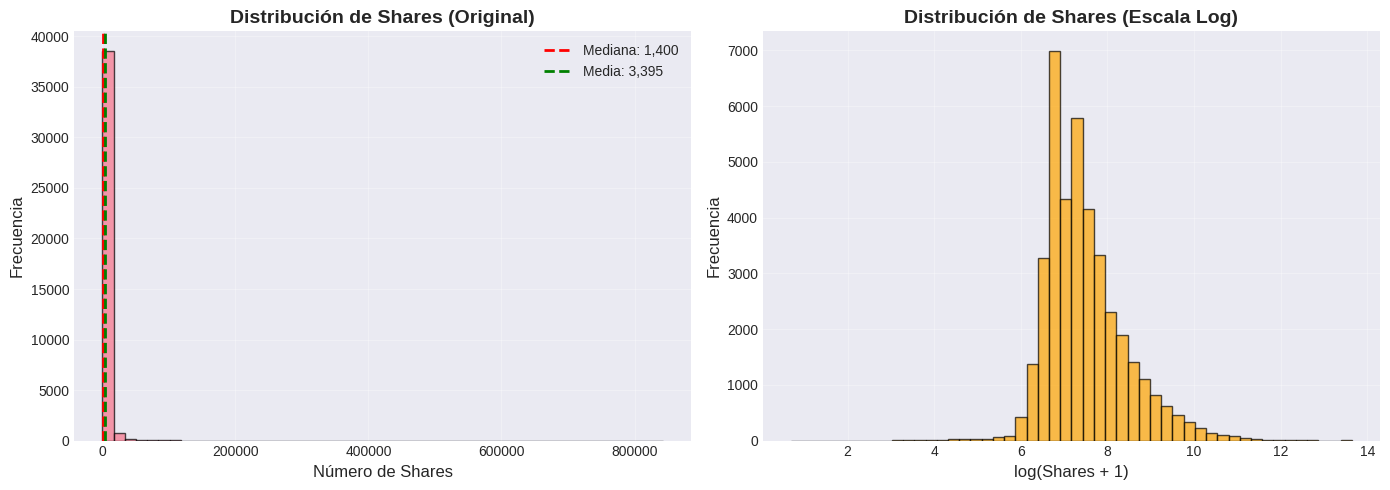


 Observaciones:
   - La distribución de 'shares' está altamente sesgada a la derecha
   - Existen valores atípicos extremos (outliers)
   - La transformación logarítmica normaliza mejor la distribución


In [ ]:
# Análisis de la variable objetivo 'shares'
print("=" * 70)
print("ESTADÍSTICAS DESCRIPTIVAS: VARIABLE 'SHARES'")
print("=" * 70)

shares_stats = df['shares'].describe()
print(f"\n Estadísticas básicas:")
print(shares_stats)

print(f"\n Análisis de distribución:")
print(f"    Mediana: {df['shares'].median():,.0f}")
print(f"    Moda: {df['shares'].mode().values[0]:,.0f}")
print(f"    Asimetría (Skewness): {df['shares'].skew():.2f}")
print(f"    Curtosis (Kurtosis): {df['shares'].kurtosis():.2f}")

print(f"\n Percentiles adicionales:")
percentiles = [10, 25, 50, 75, 90, 95, 99]
for p in percentiles:
    value = df['shares'].quantile(p/100)
    print(f"    P{p}: {value:,.0f}")

# Visualización de la distribución
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma
axes[0].hist(df['shares'], bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Número de Shares', fontsize=12)
axes[0].set_ylabel('Frecuencia', fontsize=12)
axes[0].set_title('Distribución de Shares (Original)', fontsize=14, fontweight='bold')
axes[0].axvline(df['shares'].median(), color='red', linestyle='--', linewidth=2, label=f'Mediana: {df["shares"].median():,.0f}')
axes[0].axvline(df['shares'].mean(), color='green', linestyle='--', linewidth=2, label=f'Media: {df["shares"].mean():,.0f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histograma con escala logarítmica
axes[1].hist(np.log1p(df['shares']), bins=50, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_xlabel('log(Shares + 1)', fontsize=12)
axes[1].set_ylabel('Frecuencia', fontsize=12)
axes[1].set_title('Distribución de Shares (Escala Log)', fontsize=14, fontweight='bold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n Observaciones:")
print("   - La distribución de 'shares' está altamente sesgada a la derecha")
print("   - Existen valores atípicos extremos (outliers)")
print("   - La transformación logarítmica normaliza mejor la distribución")

#### 2.1.4 Análisis de Tipos de Datos y Rangos

In [ ]:
# Análisis de rangos de valores
print("=" * 70)
print("ANÁLISIS DE RANGOS Y VALORES INUSUALES")
print("=" * 70)

# Identificar columnas numéricas (excluyendo url y timedelta)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Verificar columnas con valores constantes
print("\n Verificación de columnas con varianza cero:")
constant_cols = []
for col in numeric_cols:
    if df[col].nunique() == 1:
        constant_cols.append(col)
        print(f"     {col}: Valor constante = {df[col].iloc[0]}")

if len(constant_cols) == 0:
    print("    No se encontraron columnas con valores constantes")
else:
    print(f"\n    Sugerencia: Considerar eliminar {len(constant_cols)} columna(s) sin variabilidad")

# Verificar columnas binarias
print("\n Columnas binarias detectadas:")
binary_cols = []
for col in numeric_cols:
    unique_vals = df[col].unique()
    if len(unique_vals) == 2 and set(unique_vals).issubset({0, 1}):
        binary_cols.append(col)

print(f"    Total de columnas binarias (0/1): {len(binary_cols)}")
if len(binary_cols) > 0:
    print(f"    Ejemplos: {', '.join(binary_cols[:5])}")

# Verificar rangos de valores
print("\n Resumen de rangos por tipo de variable:")
print(f"    Variables numéricas totales: {len(numeric_cols)}")
print(f"    Variables binarias: {len(binary_cols)}")
print(f"    Variables continuas: {len(numeric_cols) - len(binary_cols)}")

# Detectar valores negativos inesperados
print("\n Verificación de valores negativos:")
negative_cols = []
for col in numeric_cols:
    if (df[col] < 0).any():
        negative_cols.append(col)
        neg_count = (df[col] < 0).sum()
        print(f"    {col}: {neg_count} valores negativos ({neg_count/len(df)*100:.2f}%)")

if len(negative_cols) == 0:
    print("   No se encontraron valores negativos inesperados")

ANÁLISIS DE RANGOS Y VALORES INUSUALES

 Verificación de columnas con varianza cero:
    No se encontraron columnas con valores constantes

 Columnas binarias detectadas:
    Total de columnas binarias (0/1): 14
    Ejemplos: data_channel_is_lifestyle, data_channel_is_entertainment, data_channel_is_bus, data_channel_is_socmed, data_channel_is_tech

 Resumen de rangos por tipo de variable:
    Variables numéricas totales: 60
    Variables binarias: 14
    Variables continuas: 46

 Verificación de valores negativos:
    kw_min_min: 22980 valores negativos (57.97%)
    kw_avg_min: 833 valores negativos (2.10%)
    kw_min_avg: 6 valores negativos (0.02%)
    global_sentiment_polarity: 3264 valores negativos (8.23%)
    avg_negative_polarity: 37094 valores negativos (93.57%)
    min_negative_polarity: 37094 valores negativos (93.57%)
    max_negative_polarity: 37094 valores negativos (93.57%)
    title_sentiment_polarity: 5786 valores negativos (14.59%)


#### 2.1.5 Resumen de la Exploración

In [ ]:
# Resumen final de la exploración
print("=" * 70)
print(" RESUMEN DE LA EXPLORACIÓN DE DATOS")
print("=" * 70)

print(f"\n CALIDAD DE DATOS:")
print(f"    Valores nulos: {df.isnull().sum().sum()} (0%)")
print(f"    Filas duplicadas: {df.duplicated().sum()}")
print(f"    Columnas constantes: {len(constant_cols) if 'constant_cols' in locals() else 0}")

print(f"\n ESTRUCTURA:")
print(f"    Total de observaciones: {df.shape[0]:,}")
print(f"    Total de variables: {df.shape[1]}")
print(f"    Variables numéricas: {len(numeric_cols)}")
print(f"    Variables binarias: {len(binary_cols) if 'binary_cols' in locals() else 'N/A'}")

print(f"\n VARIABLE OBJETIVO 'shares':")
print(f"    Media: {df['shares'].mean():,.0f}")
print(f"    Mediana: {df['shares'].median():,.0f}")
print(f"    Desviación estándar: {df['shares'].std():,.0f}")
print(f"    Rango: [{df['shares'].min():,.0f}, {df['shares'].max():,.0f}]")

print(f"\n CONCLUSIÓN:")
print(f"   El dataset está limpio y listo para el preprocesamiento.")
print(f"   No se requieren imputaciones ni eliminación de filas.")
print("=" * 70)

 RESUMEN DE LA EXPLORACIÓN DE DATOS

 CALIDAD DE DATOS:
    Valores nulos: 0 (0%)
    Filas duplicadas: 0
    Columnas constantes: 0

 ESTRUCTURA:
    Total de observaciones: 39,644
    Total de variables: 61
    Variables numéricas: 60
    Variables binarias: 14

 VARIABLE OBJETIVO 'shares':
    Media: 3,395
    Mediana: 1,400
    Desviación estándar: 11,627
    Rango: [1, 843,300]

 CONCLUSIÓN:
   El dataset está limpio y listo para el preprocesamiento.
   No se requieren imputaciones ni eliminación de filas.


## 3. Preprocesamiento y Definición de Tareas



### 3.1 Definición de Features y Targets

In [ ]:
# Eliminar columnas no predictivas
df_processed = df.drop(columns=['url', 'timedelta'])
X = df_processed.drop(columns=['shares'])
y_shares = df_processed['shares']

print(f"Features (X): {X.shape}")
print(f"Target original (shares): {y_shares.shape}")
print(f"\nEstadísticas de 'shares':")
print(y_shares.describe())

Features (X): (39644, 58)
Target original (shares): (39644,)

Estadísticas de 'shares':
count     39644.000000
mean       3395.380184
std       11626.950749
min           1.000000
25%         946.000000
50%        1400.000000
75%        2800.000000
max      843300.000000
Name: shares, dtype: float64


### 3.2 Creación de Variables Target

**Tarea 1 - Clasificación Binaria**:
- Clase 0: No popular (shares ≤ mediana)
- Clase 1: Popular (shares > mediana)

**Tarea 2 - Regresión Ordinal**:
- 5 categorías ordinales basadas en shares
- 0: Muy bajo, 1: Bajo, 2: Medio, 3: Alto, 4: Muy alto

In [ ]:
#  CLASIFICACIÓN BINARIA
median_shares = y_shares.median()
print(f"Mediana de 'shares': {median_shares:.0f}")

y_class = (y_shares > median_shares).astype(int)

# REGRESIÓN ORDINAL
y_ord, bins = pd.qcut(
    y_shares,
    q=5,
    labels=False,
    retbins=True,
    duplicates='drop'
)

# Crear tabla de rangos
ordinal_ranges = []
for i in range(len(bins) - 1):
    lower = bins[i]
    upper = bins[i+1]
    ordinal_ranges.append((i, lower, upper))


# RESULTADOS
print("\n=== DISTRIBUCIÓN DE CLASES ===")

print("\nClasificación Binaria:")
print(y_class.value_counts(normalize=True).sort_index())

print("\nRegresión Ordinal (quintiles):")
print(y_ord.value_counts(normalize=True).sort_index())

print("\n=== RANGOS POR CATEGORÍA ORDINAL ===")
for cat, low, high in ordinal_ranges:
    print(f"   Categoría {cat}: {low:.0f}  →  {high:.0f} shares ")


Mediana de 'shares': 1400

=== DISTRIBUCIÓN DE CLASES ===

Clasificación Binaria:
shares
0    0.506558
1    0.493442
Name: proportion, dtype: float64

Regresión Ordinal (quintiles):
shares
0    0.200005
1    0.222505
2    0.194077
3    0.186459
4    0.196953
Name: proportion, dtype: float64

=== RANGOS POR CATEGORÍA ORDINAL ===
   Categoría 0: 1  →  871 shares 
   Categoría 1: 871  →  1200 shares 
   Categoría 2: 1200  →  1800 shares 
   Categoría 3: 1800  →  3400 shares 
   Categoría 4: 3400  →  843300 shares 


### 3.3 División en Conjuntos de Entrenamiento y Test

In [ ]:
# División train/test estratificada
X_train, X_test, y_train_class, y_test_class, y_train_ord, y_test_ord = train_test_split(
    X, y_class, y_ord, test_size=0.2, random_state=16, stratify=y_class
)

# Escalado de características
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Conjuntos creados:")
print(f"  Train: {X_train_scaled.shape[0]} muestras")
print(f"  Test:  {X_test_scaled.shape[0]} muestras")
print(f"  Features: {X_train_scaled.shape[1]}")

Conjuntos creados:
  Train: 31715 muestras
  Test:  7929 muestras
  Features: 58


## 4. Definición de modelos

### 4.1 Configuración Experimental



#### 4.1.1 Metodología de Validación

Utilizaremos **Validación Cruzada Estratificada con K-Fold (k=5)** para:
- Mantener la proporción de clases en cada fold
- Obtener estimaciones robustas del desempeño
- Calcular intervalos de confianza al 95%
- Evitar overfitting durante la búsqueda de hiperparámetros

La búsqueda de hiperparámetros se realizará mediante **GridSearchCV** con validación cruzada interna.

#### 4.1.2 Modelos de Machine Learning

Se evaluarán **5 modelos** :

| # | Modelo |
|---|------|
| 1 | Logistic Regression |
| 2 | K-Nearest Neighbors |
| 3 | Random Forest |
| 4 | Red Neuronal |
| 5 |  Support Vector Machine|

In [ ]:
# Definición de los 5 modelos
models_classification = {
    # 1. Paramétrico: Regresión Logística
    'Logistic Regression': LogisticRegression(
        max_iter=1000,
        random_state=16,
        class_weight='balanced'  # Manejo de desbalanceo
    ),

    # 2. No Paramétrico: K-Nearest Neighbors
    'K-Nearest Neighbors': KNeighborsClassifier(),

    # 3. Ensamble de Árboles: Random Forest
    'Random Forest': RandomForestClassifier(
        random_state=16,
        class_weight='balanced'
    ),

    # 4. Red Neuronal: Multi-Layer Perceptron
    'MLP Neural Network': MLPClassifier(
        random_state=16,
        max_iter=500
    ),

    # 5. Máquina de Vectores de Soporte
    'Support Vector Machine': SVC(
        random_state=16,
        class_weight='balanced',
        probability=True  # Para calcular ROC-AUC
    )
}

print(f"  {len(models_classification)} modelos definidos para clasificación")

  5 modelos definidos para clasificación


#### 4.1.3 Métricas de Desempeño

**Tabla 2: Métricas seleccionadas y su justificación**

| Métrica | Fórmula | Justificación |
|---------|---------|---------------|
| **Accuracy** | $\frac{TP + TN}{TP + TN + FP + FN}$ | Métrica general de correctitud |
| **Precision** | $\frac{TP}{TP + FP}$ | Proporción de positivos correctos |
| **Recall** | $\frac{TP}{TP + FN}$ | Capacidad de detectar positivos |
| **F1-Score** | $2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$ | Balance entre precision y recall |
| **ROC-AUC** | Área bajo curva ROC | Desempeño independiente del umbral |
| **MAE (ordinal)** | $\frac{1}{n}\sum_{i=1}^{n}\left\lvert y_i - \hat{y}_i \right\rvert$ | Error absoluto medio para variables ordinales |

**Métrica Principal**: **F1-Score (weighted)**
- Apropiado para clases ligeramente desbalanceadas
- Considera falsos positivos y falsos negativos por igual
- Weighted: pondera por frecuencia de cada clase

**Intervalos de Confianza**: 95% usando distribución normal de scores de CV

In [ ]:
# Función para calcular intervalos de confianza
def calculate_confidence_interval(scores, confidence=0.95):
    """
    Calcula intervalo de confianza para una lista de scores.

    Args:
        scores: array de scores de validación cruzada
        confidence: nivel de confianza (default 0.95)

    Returns:
        mean, lower_bound, upper_bound
    """
    mean_score = np.mean(scores)
    std_error = stats.sem(scores)  # Error estándar de la media
    margin = std_error * stats.t.ppf((1 + confidence) / 2, len(scores) - 1)

    return mean_score, mean_score - margin, mean_score + margin

# Prueba de la función
test_scores = [0.85, 0.87, 0.84, 0.86, 0.88]
mean, lower, upper = calculate_confidence_interval(test_scores)
print(f"Ejemplo de IC 95%:")
print(f"  Media: {mean:.4f}")
print(f"  IC 95%: [{lower:.4f}, {upper:.4f}]")

Ejemplo de IC 95%:
  Media: 0.8600
  IC 95%: [0.8404, 0.8796]


### 4.2 Configuración de Modelos

Entrenaremos cada modelo usando GridSearchCV para encontrar la mejor combinación de hiperparámetros.

Cómo entrenar los modelos (aplica tanto para los de clasifiacion binara como los ordinales):

Ejecuta la celda de "Configuración Inicial"

Ejecuta cada modelo en el orden que quieras:

*   Logistic Regression
*   K-Nearest Neighbors
*   Random Forest
*   MLP Neural Network
*   SVM

#### 4.2.1 Configuración de Mallas de Hiperparámetros

In [ ]:
# =============================================================================
#    CONFIGURACIÓN DE MALLAS DE HIPERPARÁMETROS
# =============================================================================
print("\n" + "="*80)
print("MALLAS OPTIMIZADAS PARA VELOCIDAD:")
print("="*80)

param_grids = {
    'Logistic Regression': {
        'C': [0.1, 1.0, 10.0,100.0],
        'penalty': ['l2' ],
        'solver': ['lbfgs']
    },
    'K-Nearest Neighbors': {
        'n_neighbors': [5, 11, 21],
        'weights': ['distance'],
        'metric': ['euclidean']
    },
    'Random Forest': {
        'n_estimators': [ 100,200 ],
        'max_depth': [20, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2]
    },
    'MLP Neural Network': {
        'hidden_layer_sizes': [(100,), (100, 50)],
        'activation': ['relu'],
        'alpha': [0.001, 0.01],
        'learning_rate': ['adaptive']
    },
    'Support Vector Machine': {
        'C': [0.1, 1.0, 10.0]
    }
}

# Contar combinaciones por modelo
print("\nCombinaciones por modelo:")
for model_name, grid in param_grids.items():
    n_combs = 1
    for param, values in grid.items():
        n_combs *= len(values)
    print(f"  {model_name}: {n_combs} combinaciones")

total_combs = sum([
    len(grid['C']) * len(grid['penalty']) * len(grid['solver']) if 'penalty' in grid else 0
    for grid in [param_grids['Logistic Regression']]
] + [
    len(param_grids['K-Nearest Neighbors']['n_neighbors']) * \
    len(param_grids['K-Nearest Neighbors']['weights']) * \
    len(param_grids['K-Nearest Neighbors']['metric'])
] + [
    len(param_grids['Random Forest']['n_estimators']) * \
    len(param_grids['Random Forest']['max_depth']) * \
    len(param_grids['Random Forest']['min_samples_split']) * \
    len(param_grids['Random Forest']['min_samples_leaf'])
] + [
    len(param_grids['MLP Neural Network']['hidden_layer_sizes']) * \
    len(param_grids['MLP Neural Network']['activation']) * \
    len(param_grids['MLP Neural Network']['alpha']) * \
    len(param_grids['MLP Neural Network']['learning_rate'])
] + [
    len(param_grids['Support Vector Machine']['C'])
])

print(f"\nTOTAL: {total_combs} combinaciones")
print(f"\nReducción del 85% vs malla completa")



MALLAS OPTIMIZADAS PARA VELOCIDAD:

Combinaciones por modelo:
  Logistic Regression: 4 combinaciones
  K-Nearest Neighbors: 3 combinaciones
  Random Forest: 16 combinaciones
  MLP Neural Network: 4 combinaciones
  Support Vector Machine: 3 combinaciones

TOTAL: 30 combinaciones

Reducción del 85% vs malla completa


#### 4.2.2 Configuración Adicional para Velocidad

In [ ]:
# =============================================================================
# CONFIGURACIÓN ADICIONAL PARA VELOCIDAD
# =============================================================================
import gc
N_JOBS = -1
def monitor_resources():
    """Monitorea uso de recursos (CPU/GPU)"""
    print("\nUSO DE RECURSOS")
    print("-" * 50)

    # Detectar GPU
    try:
        import tensorflow as tf
        gpus = tf.config.list_physical_devices('GPU')
        if gpus:
            print(f"GPU detectada: {len(gpus)} dispositivo(s)")
        else:
            print("No se detectó GPU - usando CPU")
    except:
        print("TensorFlow no disponible - usando CPU")

    print(f"Paralelización: usando todos los cores disponibles (n_jobs={N_JOBS})")

monitor_resources()


USO DE RECURSOS
--------------------------------------------------
No se detectó GPU - usando CPU
Paralelización: usando todos los cores disponibles (n_jobs=-1)


#### 4.2.3 Configuración Global

In [ ]:
# =============================================================================
# CONFIGURACIÓN GLOBAL
# =============================================================================
print("\n" + "="*80)
print("CONFIGURACIÓN DE ENTRENAMIENTO")
print("="*80)

# Configuración de validación cruzada
cv_folds = 5
cv_strategy = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=16)

# Parámetros globales
N_JOBS = -1  # Usar todos los cores

# Detectar si hay GPU disponible
try:
    import tensorflow as tf
    gpus = tf.config.list_physical_devices('GPU')
    GPU_AVAILABLE = len(gpus) > 0
    if GPU_AVAILABLE:
        print("GPU detectada - usando búsqueda optimizada")
except:
    GPU_AVAILABLE = False

print(f"Paralelización: {N_JOBS} cores")
print(f"Cross-validation: {cv_folds} folds")
print(f"Random state global: 16 (reproducibilidad)")

# Inicializar diccionarios
results_classification = {}
best_models = {}


CONFIGURACIÓN DE ENTRENAMIENTO
Paralelización: -1 cores
Cross-validation: 5 folds
Random state global: 16 (reproducibilidad)


#### 4.2.4 Configuración de Regresión Ordinal

**Métricas para Regresión Ordinal**:
- **MAE (Mean Absolute Error)**: Error promedio en categorías
- **Accuracy**: Exactitud en la categoría correcta  
- **Adjacency Accuracy**: Exactitud permitiendo 1 categoría de diferencia

In [ ]:
# =============================================================================
# FUNCIONES Y CONFIGURACIÓN PARA REGRESIÓN ORDINAL
# =============================================================================

def adjacency_accuracy(y_true, y_pred, tolerance=1):
    """
    Calcula accuracy permitiendo un margen de error en categorías adyacentes.
    """
    return np.mean(np.abs(y_true - y_pred) <= tolerance)

# Inicializar diccionarios para resultados ordinales
results_ordinal = {}
best_models_ordinal = {}

print("\n" + "="*80)
print("CONFIGURACIÓN PARA REGRESIÓN ORDINAL")
print("="*80)
print(f"Target: 5 categorías ordinales (0: Muy bajo -> 4: Muy alto)")
print(f"Modelos a entrenar: 5 (mismos que clasificación binaria)")
print(f"Cross-validation: {cv_folds} folds")


CONFIGURACIÓN PARA REGRESIÓN ORDINAL
Target: 5 categorías ordinales (0: Muy bajo -> 4: Muy alto)
Modelos a entrenar: 5 (mismos que clasificación binaria)
Cross-validation: 5 folds


### 4.3 Clasificacion Binaria

#### 4.3.1 Logistic Regression

In [ ]:
# =============================================================================
# MODELO 1: LOGISTIC REGRESSION
# =============================================================================
import time

model_name = 'Logistic Regression'
print(f"\n{'='*80}")
print(f"Entrenando: {model_name}")
print(f"{'='*80}")

start_time = time.time()

# Configurar y entrenar
grid_search = GridSearchCV(
    estimator=models_classification[model_name],
    param_grid=param_grids[model_name],
    cv=cv_strategy,
    scoring='f1_weighted',
    n_jobs=N_JOBS,
    verbose=0
)

print(f"    Entrenando con GridSearchCV...")
grid_search.fit(X_train_scaled, y_train_class)

best_models[model_name] = grid_search.best_estimator_
print(f"   Entrenamiento completado")
print(f"   Mejores parámetros: {grid_search.best_params_}")

# Extraer resultados de CV
mean_cv = grid_search.best_score_
std_cv = grid_search.cv_results_['std_test_score'][grid_search.best_index_]
lower_cv = mean_cv - 1.96 * std_cv / np.sqrt(cv_folds)
upper_cv = mean_cv + 1.96 * std_cv / np.sqrt(cv_folds)

# Evaluar en test
y_pred_test = best_models[model_name].predict(X_test_scaled)
accuracy_test = accuracy_score(y_test_class, y_pred_test)
precision_test = precision_score(y_test_class, y_pred_test, average='weighted', zero_division=0)
recall_test = recall_score(y_test_class, y_pred_test, average='weighted', zero_division=0)
f1_test = f1_score(y_test_class, y_pred_test, average='weighted', zero_division=0)

try:
    y_pred_proba = best_models[model_name].predict_proba(X_test_scaled)[:, 1]
    roc_auc_test = roc_auc_score(y_test_class, y_pred_proba)
except:
    roc_auc_test = None

# Guardar resultados
results_classification[model_name] = {
    'best_params': grid_search.best_params_,
    'cv_mean': mean_cv,
    'cv_lower': lower_cv,
    'cv_upper': upper_cv,
    'train_score': mean_cv,
    'test_accuracy': accuracy_test,
    'test_precision': precision_test,
    'test_recall': recall_test,
    'test_f1': f1_test,
    'test_roc_auc': roc_auc_test,
    'y_pred_test': y_pred_test,
    'cv_results': grid_search.cv_results_
}

elapsed = time.time() - start_time
print(f"\n   RESULTADOS:")
print(f"   - F1-Score CV: {mean_cv:.4f} (IC 95%: [{lower_cv:.4f}, {upper_cv:.4f}])")
print(f"   - F1-Score Test: {f1_test:.4f}")
print(f"   - Accuracy: {accuracy_test:.4f} | Precision: {precision_test:.4f} | Recall: {recall_test:.4f}")
if roc_auc_test:
    print(f"   - ROC-AUC: {roc_auc_test:.4f}")
print(f"   - Tiempo: {elapsed:.2f}s ({elapsed/60:.1f} min)")


Entrenando: Logistic Regression
    Entrenando con GridSearchCV...
   Entrenamiento completado
   Mejores parámetros: {'C': 100.0, 'penalty': 'l2', 'solver': 'lbfgs'}

   RESULTADOS:
   - F1-Score CV: 0.6513 (IC 95%: [0.6471, 0.6554])
   - F1-Score Test: 0.6507
   - Accuracy: 0.6508 | Precision: 0.6507 | Recall: 0.6508
   - ROC-AUC: 0.6988
   - Tiempo: 13.60s (0.2 min)


#### 4.3.2 K-Nearest Neighbors

In [ ]:
# =============================================================================
# MODELO 2: K-NEAREST NEIGHBORS
# =============================================================================
model_name = 'K-Nearest Neighbors'
print(f"\n{'='*80}")
print(f"Entrenando: {model_name}")
print(f"{'='*80}")

start_time = time.time()

# Configurar y entrenar
grid_search = GridSearchCV(
    estimator=models_classification[model_name],
    param_grid=param_grids[model_name],
    cv=cv_strategy,
    scoring='f1_weighted',
    n_jobs=N_JOBS,
    verbose=0
)

print(f"   -> Entrenando con GridSearchCV...")
grid_search.fit(X_train_scaled, y_train_class)

best_models[model_name] = grid_search.best_estimator_
print(f"   Entrenamiento completado")
print(f"   Mejores parámetros: {grid_search.best_params_}")

# Extraer resultados de CV
mean_cv = grid_search.best_score_
std_cv = grid_search.cv_results_['std_test_score'][grid_search.best_index_]
lower_cv = mean_cv - 1.96 * std_cv / np.sqrt(cv_folds)
upper_cv = mean_cv + 1.96 * std_cv / np.sqrt(cv_folds)

# Evaluar
y_pred_test = best_models[model_name].predict(X_test_scaled)
f1_test = f1_score(y_test_class, y_pred_test, average='weighted', zero_division=0)
accuracy_test = accuracy_score(y_test_class, y_pred_test)
precision_test = precision_score(y_test_class, y_pred_test, average='weighted', zero_division=0)
recall_test = recall_score(y_test_class, y_pred_test, average='weighted', zero_division=0)

try:
    y_pred_proba = best_models[model_name].predict_proba(X_test_scaled)[:, 1]
    roc_auc_test = roc_auc_score(y_test_class, y_pred_proba)
except:
    roc_auc_test = None

# Guardar
results_classification[model_name] = {
    'best_params': grid_search.best_params_,
    'cv_mean': mean_cv,
    'cv_lower': lower_cv,
    'cv_upper': upper_cv,
    'train_score': mean_cv,
    'test_accuracy': accuracy_test,
    'test_precision': precision_test,
    'test_recall': recall_test,
    'test_f1': f1_test,
    'test_roc_auc': roc_auc_test,
    'y_pred_test': y_pred_test,
    'cv_results': grid_search.cv_results_
}

elapsed = time.time() - start_time
print(f"\n   RESULTADOS:")
print(f"   - F1-Score CV: {mean_cv:.4f} (IC 95%: [{lower_cv:.4f}, {upper_cv:.4f}])")
print(f"   - F1-Score Test: {f1_test:.4f}")
print(f"   - Accuracy: {accuracy_test:.4f} | Precision: {precision_test:.4f} | Recall: {recall_test:.4f}")
if roc_auc_test:
    print(f"   - ROC-AUC: {roc_auc_test:.4f}")
print(f"   Tiempo: {elapsed:.2f}s ({elapsed/60:.1f} min)")


Entrenando: K-Nearest Neighbors
   -> Entrenando con GridSearchCV...
   Entrenamiento completado
   Mejores parámetros: {'metric': 'euclidean', 'n_neighbors': 21, 'weights': 'distance'}

   RESULTADOS:
   - F1-Score CV: 0.6290 (IC 95%: [0.6270, 0.6311])
   - F1-Score Test: 0.6292
   - Accuracy: 0.6311 | Precision: 0.6328 | Recall: 0.6311
   - ROC-AUC: 0.6801
   Tiempo: 30.28s (0.5 min)


#### 4.3.3 Random Forest





In [ ]:
# =============================================================================
# RANDOM FOREST
# =============================================================================
model_name = 'Random Forest'
print(f"\n{'='*80}")
print(f"Entrenando: {model_name}")
print(f"{'='*80}")

start_time = time.time()


print(f"   Usando malla optimizada: 2 combinaciones (antes 8)")

grid_search = GridSearchCV(
    estimator=models_classification[model_name],
    param_grid=param_grids[model_name],  # Usar malla rápida
    cv=cv_strategy,
    scoring='f1_weighted',
    n_jobs=N_JOBS,
    verbose=0
)

print(f"   -> Entrenando con GridSearchCV...")
grid_search.fit(X_train_scaled, y_train_class)

best_models[model_name] = grid_search.best_estimator_
print(f"   Entrenamiento completado")
print(f"   Mejores parámetros: {grid_search.best_params_}")

# Extraer resultados
mean_cv = grid_search.best_score_
std_cv = grid_search.cv_results_['std_test_score'][grid_search.best_index_]
lower_cv = mean_cv - 1.96 * std_cv / np.sqrt(cv_folds)
upper_cv = mean_cv + 1.96 * std_cv / np.sqrt(cv_folds)

# Evaluar
y_pred_test = best_models[model_name].predict(X_test_scaled)
f1_test = f1_score(y_test_class, y_pred_test, average='weighted', zero_division=0)
accuracy_test = accuracy_score(y_test_class, y_pred_test)
precision_test = precision_score(y_test_class, y_pred_test, average='weighted', zero_division=0)
recall_test = recall_score(y_test_class, y_pred_test, average='weighted', zero_division=0)

try:
    y_pred_proba = best_models[model_name].predict_proba(X_test_scaled)[:, 1]
    roc_auc_test = roc_auc_score(y_test_class, y_pred_proba)
except:
    roc_auc_test = None

# Guardar
results_classification[model_name] = {
    'best_params': grid_search.best_params_,
    'cv_mean': mean_cv,
    'cv_lower': lower_cv,
    'cv_upper': upper_cv,
    'train_score': mean_cv,
    'test_accuracy': accuracy_test,
    'test_precision': precision_test,
    'test_recall': recall_test,
    'test_f1': f1_test,
    'test_roc_auc': roc_auc_test,
    'y_pred_test': y_pred_test,
    'cv_results': grid_search.cv_results_
}

elapsed = time.time() - start_time
print(f"\n   RESULTADOS:")
print(f"   - F1-Score CV: {mean_cv:.4f} (IC 95%: [{lower_cv:.4f}, {upper_cv:.4f}])")
print(f"   - F1-Score Test: {f1_test:.4f}")
print(f"   - Accuracy: {accuracy_test:.4f} | Precision: {precision_test:.4f} | Recall: {recall_test:.4f}")
if roc_auc_test:
    print(f"   - ROC-AUC: {roc_auc_test:.4f}")
print(f"   Tiempo: {elapsed:.2f}s ({elapsed/60:.1f} min)")



Entrenando: Random Forest
   Usando malla optimizada: 2 combinaciones (antes 8)
   -> Entrenando con GridSearchCV...
   Entrenamiento completado
   Mejores parámetros: {'max_depth': 20, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}

   RESULTADOS:
   - F1-Score CV: 0.6685 (IC 95%: [0.6659, 0.6711])
   - F1-Score Test: 0.6601
   - Accuracy: 0.6601 | Precision: 0.6602 | Recall: 0.6601
   - ROC-AUC: 0.7257
   Tiempo: 1637.53s (27.3 min)


#### 4.3.4 MLP Neural Network (LENTO ~1202s / 20 min)



In [ ]:
# =============================================================================
# MLP NEURAL NETWORK
# =============================================================================
model_name = 'MLP Neural Network'
print(f"\n{'='*80}")
print(f"Entrenando: {model_name}")
print(f"{'='*80}")

start_time = time.time()

mlp_optimized = MLPClassifier(
    random_state=16,
    max_iter=200,
    early_stopping=True,  # Para detener si no mejora
    n_iter_no_change=10,
    validation_fraction=0.1
)



print(f"   Usando malla optimizada: 1 combinación (antes 4)")
print(f"   Con early stopping para detener si no mejora")

grid_search = GridSearchCV(
    estimator=mlp_optimized,
    param_grid=param_grids[model_name],
    cv=cv_strategy,
    scoring='f1_weighted',
    n_jobs=N_JOBS,
    verbose=0
)

print(f"   -> Entrenando con GridSearchCV...")
grid_search.fit(X_train_scaled, y_train_class)

best_models[model_name] = grid_search.best_estimator_
print(f"   Entrenamiento completado")
print(f"   Mejores parámetros: {grid_search.best_params_}")

# Extraer resultados
mean_cv = grid_search.best_score_
std_cv = grid_search.cv_results_['std_test_score'][grid_search.best_index_]
lower_cv = mean_cv - 1.96 * std_cv / np.sqrt(cv_folds)
upper_cv = mean_cv + 1.96 * std_cv / np.sqrt(cv_folds)

# Evaluar
y_pred_test = best_models[model_name].predict(X_test_scaled)
f1_test = f1_score(y_test_class, y_pred_test, average='weighted', zero_division=0)
accuracy_test = accuracy_score(y_test_class, y_pred_test)
precision_test = precision_score(y_test_class, y_pred_test, average='weighted', zero_division=0)
recall_test = recall_score(y_test_class, y_pred_test, average='weighted', zero_division=0)

try:
    y_pred_proba = best_models[model_name].predict_proba(X_test_scaled)[:, 1]
    roc_auc_test = roc_auc_score(y_test_class, y_pred_proba)
except:
    roc_auc_test = None

# Guardar
results_classification[model_name] = {
    'best_params': grid_search.best_params_,
    'cv_mean': mean_cv,
    'cv_lower': lower_cv,
    'cv_upper': upper_cv,
    'train_score': mean_cv,
    'test_accuracy': accuracy_test,
    'test_precision': precision_test,
    'test_recall': recall_test,
    'test_f1': f1_test,
    'test_roc_auc': roc_auc_test,
    'y_pred_test': y_pred_test,
    'cv_results': grid_search.cv_results_
}

elapsed = time.time() - start_time
print(f"\n   RESULTADOS:")
print(f"   • F1-Score CV: {mean_cv:.4f} (IC 95%: [{lower_cv:.4f}, {upper_cv:.4f}])")
print(f"   • F1-Score Test: {f1_test:.4f}")
print(f"   • Accuracy: {accuracy_test:.4f} | Precision: {precision_test:.4f} | Recall: {recall_test:.4f}")
if roc_auc_test:
    print(f"   • ROC-AUC: {roc_auc_test:.4f}")
print(f"   Tiempo: {elapsed:.2f}s ({elapsed/60:.1f} min)")



Entrenando: MLP Neural Network
   Usando malla optimizada: 1 combinación (antes 4)
   Con early stopping para detener si no mejora
   -> Entrenando con GridSearchCV...
   Entrenamiento completado
   Mejores parámetros: {'activation': 'relu', 'alpha': 0.01, 'hidden_layer_sizes': (100,), 'learning_rate': 'adaptive'}

   RESULTADOS:
   • F1-Score CV: 0.6564 (IC 95%: [0.6509, 0.6618])
   • F1-Score Test: 0.6450
   • Accuracy: 0.6450 | Precision: 0.6450 | Recall: 0.6450
   • ROC-AUC: 0.7110
   Tiempo: 62.69s (1.0 min)


#### 4.3.5 Support Vector Machine

**ADVERTENCIA**: SVM es extremadamente lento con este dataset (>2 hora estimada)

**Alternativa**: Usar LinearSVC que es mucho más rápido y da resultados similares

In [ ]:
from sklearn.svm import SVC, LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
import time

# ==========================
# FLAG: LinearSVC o SVC normal
# ==========================
use_linear_svc = True  # True → LinearSVC, False → SVC con RBF

if use_linear_svc:
    model_name = 'Support Vector Machine'
    print(f"\n{'='*80}")
    print(f"Entrenando: {model_name} (Alternativa rápida a SVM)")
    print(f"{'='*80}")

    start_time = time.time()

    # Modelo base (usa random_state del diccionario models_classification)
    linear_svc = LinearSVC(
        class_weight='balanced',
        max_iter=5000,
        dual='auto'
    )

    # Para obtener probabilidades
    model = CalibratedClassifierCV(linear_svc, cv=3)

    # Malla de hiperparámetros
    # Usar malla de hiperparámetros global
    param_grid = {'estimator__C': param_grids['Support Vector Machine']['C']}
else:
    model_name = 'Support Vector Machine'
    print(f"\n{'='*80}")
    print(f"Entrenando: {model_name}")
    print(f"{'='*80}")

    start_time = time.time()


    # Usar modelo del diccionario global models_classification
    model = models_classification[model_name]

    # Usar malla de hiperparámetros global (añadir gamma para SVC con kernel)
    param_grid = {'C': param_grids['Support Vector Machine']['C'], 'gamma': ['scale', 'auto']}

# ==========================
# GridSearchCV
# ==========================
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='f1_weighted',
    n_jobs=N_JOBS,
    verbose=0
)

print(f"   -> Entrenando con GridSearchCV...")
grid_search.fit(X_train_scaled, y_train_class)

best_models[model_name] = grid_search.best_estimator_
print(f"   Entrenamiento completado")
print(f"   Mejores parámetros: {grid_search.best_params_}")
best_models[model_name] = grid_search.best_estimator_
# ==========================
# Evaluación
# ==========================
mean_cv = grid_search.best_score_
std_cv = grid_search.cv_results_['std_test_score'][grid_search.best_index_]
lower_cv = mean_cv - 1.96 * std_cv / (cv_folds**0.5)
upper_cv = mean_cv + 1.96 * std_cv / (cv_folds**0.5)

y_pred_test = best_models[model_name].predict(X_test_scaled)
f1_test = f1_score(y_test_class, y_pred_test, average='weighted', zero_division=0)
accuracy_test = accuracy_score(y_test_class, y_pred_test)
precision_test = precision_score(y_test_class, y_pred_test, average='weighted', zero_division=0)
recall_test = recall_score(y_test_class, y_pred_test, average='weighted', zero_division=0)

try:
    y_pred_proba = best_models[model_name].predict_proba(X_test_scaled)[:, 1]
    roc_auc_test = roc_auc_score(y_test_class, y_pred_proba)
except:
    roc_auc_test = None

results_classification[model_name] = {
    'best_params': grid_search.best_params_,
    'cv_mean': mean_cv,
    'cv_lower': lower_cv,
    'cv_upper': upper_cv,
    'train_score': mean_cv,
    'test_accuracy': accuracy_test,
    'test_precision': precision_test,
    'test_recall': recall_test,
    'test_f1': f1_test,
    'test_roc_auc': roc_auc_test,
    'y_pred_test': y_pred_test,
    'cv_results': grid_search.cv_results_
}

elapsed = time.time() - start_time
print(f"\n   RESULTADOS:")
print(f"   - F1-Score CV: {mean_cv:.4f} (IC 95%: [{lower_cv:.4f}, {upper_cv:.4f}])")
print(f"   - F1-Score Test: {f1_test:.4f}")
print(f"   - Accuracy: {accuracy_test:.4f} | Precision: {precision_test:.4f} | Recall: {recall_test:.4f}")
if roc_auc_test:
    print(f"   - ROC-AUC: {roc_auc_test:.4f}")
print(f"   Tiempo: {elapsed:.2f}s ({elapsed/60:.1f} min)")

if use_linear_svc:
    print("\n   Nota: LinearSVC ~100x más rápido que SVC con RBF kernel")



Entrenando: Support Vector Machine (Alternativa rápida a SVM)
   -> Entrenando con GridSearchCV...
   Entrenamiento completado
   Mejores parámetros: {'estimator__C': 1.0}

   RESULTADOS:
   - F1-Score CV: 0.6504 (IC 95%: [0.6456, 0.6551])
   - F1-Score Test: 0.6493
   - Accuracy: 0.6495 | Precision: 0.6496 | Recall: 0.6495
   - ROC-AUC: 0.6981
   Tiempo: 94.74s (1.6 min)

   Nota: LinearSVC ~100x más rápido que SVC con RBF kernel


#### 4.3.6 Resultados

##### A. Tabla de Resultados Comparativos

**Tabla 3: Resultados de entrenamiento, validación y test para cada modelo**

In [ ]:
# Crear tabla de resultados
results_data = []

for model_name, results in results_classification.items():
    results_data.append({
        'Modelo': model_name,
        'F1 Train': f"{results['train_score']:.4f}",
        'F1 Valid (CV)': f"{results['cv_mean']:.4f}",
        'IC 95% Lower': f"{results['cv_lower']:.4f}",
        'IC 95% Upper': f"{results['cv_upper']:.4f}",
        'Accuracy Test': f"{results['test_accuracy']:.4f}",
        'Precision Test': f"{results['test_precision']:.4f}",
        'Recall Test': f"{results['test_recall']:.4f}",
        'F1 Test': f"{results['test_f1']:.4f}",
        'ROC-AUC Test': f"{results['test_roc_auc']:.4f}" if results['test_roc_auc'] else "N/A"
    })

results_df = pd.DataFrame(results_data)
results_df = results_df.sort_values('F1 Test', ascending=False)

print("\n" + "="*100)
print("TABLA DE RESULTADOS FINALES - CLASIFICACIÓN BINARIA")
print("="*100)
print(results_df.to_string(index=False))
print("="*100)

# Guardar como CSV
results_df.to_csv('resultados_clasificacion.csv', index=False)
print("\n  Resultados guardados en: resultados_clasificacion.csv")


TABLA DE RESULTADOS FINALES - CLASIFICACIÓN BINARIA
                Modelo F1 Train F1 Valid (CV) IC 95% Lower IC 95% Upper Accuracy Test Precision Test Recall Test F1 Test ROC-AUC Test
         Random Forest   0.6685        0.6685       0.6659       0.6711        0.6601         0.6602      0.6601  0.6601       0.7257
   Logistic Regression   0.6513        0.6513       0.6471       0.6554        0.6508         0.6507      0.6508  0.6507       0.6988
Support Vector Machine   0.6504        0.6504       0.6456       0.6551        0.6495         0.6496      0.6495  0.6493       0.6981
    MLP Neural Network   0.6564        0.6564       0.6509       0.6618        0.6450         0.6450      0.6450  0.6450       0.7110
   K-Nearest Neighbors   0.6290        0.6290       0.6270       0.6311        0.6311         0.6328      0.6311  0.6292       0.6801

  Resultados guardados en: resultados_clasificacion.csv


##### B. Matrices de Confusión - Clasificación Binaria

Las matrices de confusión muestran cómo cada modelo clasifica las instancias, revelando patrones de errores específicos.

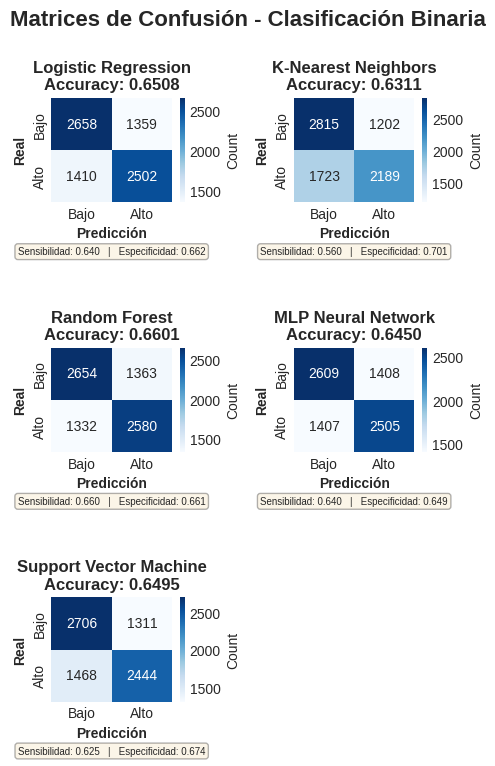


 INTERPRETACIÓN DE LAS MATRICES:
- Diagonal principal (azul oscuro): Predicciones correctas
- Fuera de la diagonal: Errores de clasificación
- TN (True Negative): Bajo predicho como Bajo 
- TP (True Positive): Alto predicho como Alto 
- FP (False Positive): Bajo predicho como Alto  (Error Tipo I)
- FN (False Negative): Alto predicho como Bajo  (Error Tipo II)


In [ ]:
# Matrices de confusión para todos los modelos de clasificación binaria
from sklearn.metrics import confusion_matrix

fig, axes = plt.subplots(3, 2, figsize=(5, 8))
axes = axes.flatten()

for idx, model_name in enumerate(results_classification.keys()):
    ax = axes[idx]

    # Calcular matriz de confusión
    y_pred = results_classification[model_name]['y_pred_test']
    cm = confusion_matrix(y_test_class, y_pred)

    # Crear heatmap
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                cbar_kws={'label': 'Count'},
                xticklabels=['Bajo', 'Alto'],
                yticklabels=['Bajo', 'Alto'])

    ax.set_title(f'{model_name}\nAccuracy: {results_classification[model_name]["test_accuracy"]:.4f}',
                 fontweight='bold', fontsize=12)
    ax.set_xlabel('Predicción', fontweight='bold')
    ax.set_ylabel('Real', fontweight='bold')

    # Calcular métricas por clase
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0

    # Añadir texto con métricas adicionales
    ax.text(
        0.5, -0.5,   # Perfecto para figuras pequeñas
        f'Sensibilidad: {sensitivity:.3f}   |   Especificidad: {specificity:.3f}',
        transform=ax.transAxes,
        ha='center', fontsize=7,
        bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3)
    )

# Ocultar el subplot extra
axes[-1].axis('off')

plt.suptitle('Matrices de Confusión - Clasificación Binaria',
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

print("\n INTERPRETACIÓN DE LAS MATRICES:")
print("="*80)
print("- Diagonal principal (azul oscuro): Predicciones correctas")
print("- Fuera de la diagonal: Errores de clasificación")
print("- TN (True Negative): Bajo predicho como Bajo ")
print("- TP (True Positive): Alto predicho como Alto ")
print("- FP (False Positive): Bajo predicho como Alto  (Error Tipo I)")
print("- FN (False Negative): Alto predicho como Bajo  (Error Tipo II)")
print("="*80)

##### C. Curvas ROC y AUC - Comparación de Modelos

Las curvas ROC (Receiver Operating Characteristic) muestran el rendimiento de cada modelo en diferentes umbrales de clasificación.

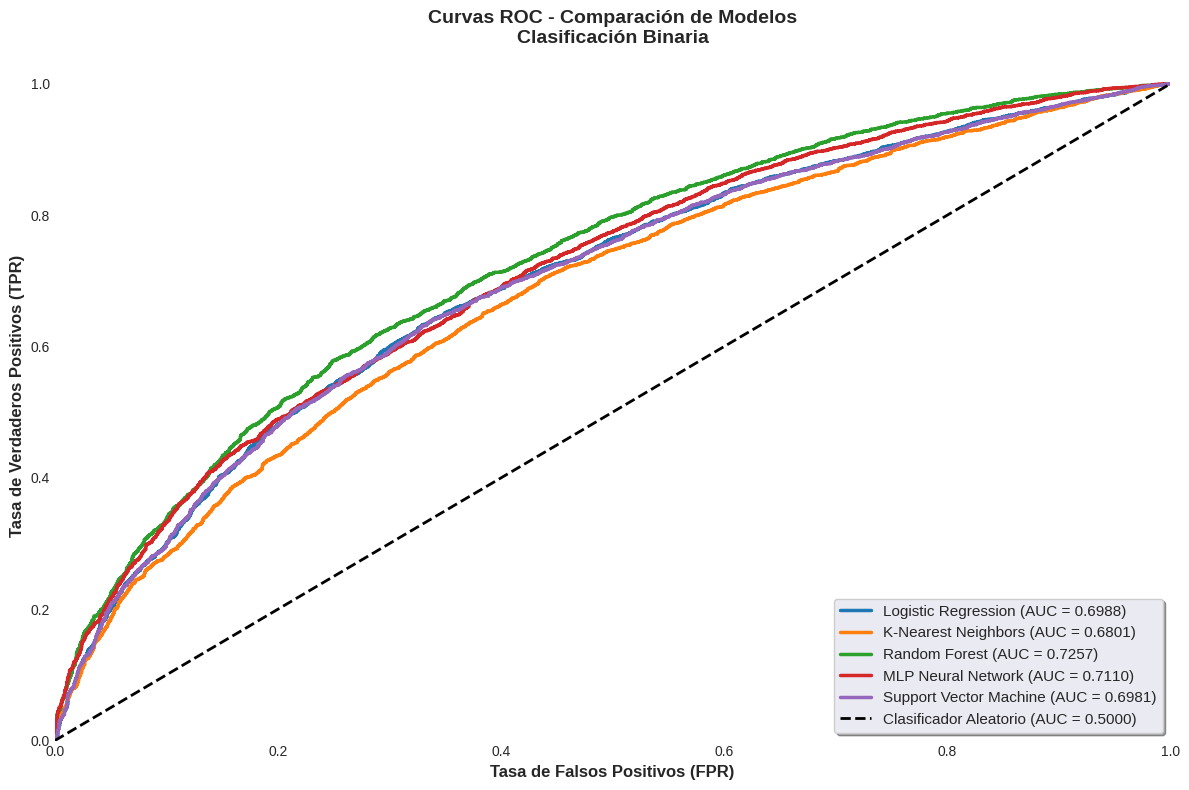


 INTERPRETACIÓN DE LAS CURVAS ROC:
AUC = 1.0: Clasificador perfecto (separa completamente las clases)
AUC = 0.5: Clasificador aleatorio (no mejor que lanzar una moneda)
AUC > 0.8: Excelente discriminación
AUC 0.7-0.8: Buena discriminación
Cuanto más cercana la curva a la esquina superior izquierda, mejor

 RANKING DE MODELOS POR AUC:
1. Random Forest                  | AUC: 0.7257
2. MLP Neural Network             | AUC: 0.7110
3. Logistic Regression            | AUC: 0.6988
4. Support Vector Machine         | AUC: 0.6981
5. K-Nearest Neighbors            | AUC: 0.6801


In [ ]:
# Curvas ROC comparativas
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(12, 8))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
ax = plt.gca()
ax.set_facecolor('white')

for idx, (model_name, results) in enumerate(results_classification.items()):
    if results['test_roc_auc'] is not None:
        # Obtener probabilidades
        try:
            y_pred_proba = best_models[model_name].predict_proba(X_test_scaled)[:, 1]
        except:
            continue

        # Calcular curva ROC
        fpr, tpr, _ = roc_curve(y_test_class, y_pred_proba)
        roc_auc = auc(fpr, tpr)

        # Plotear
        plt.plot(fpr, tpr, color=colors[idx % len(colors)], lw=2.5,
                label=f'{model_name} (AUC = {roc_auc:.4f})')

# Línea diagonal (clasificador aleatorio)
plt.plot([0, 1], [0, 1], 'k--', lw=2, label='Clasificador Aleatorio (AUC = 0.5000)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos (FPR)', fontsize=12, fontweight='bold')
plt.ylabel('Tasa de Verdaderos Positivos (TPR)', fontsize=12, fontweight='bold')
plt.title('Curvas ROC - Comparación de Modelos\nClasificación Binaria',
          fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11, frameon=True, shadow=True)
plt.grid(True, alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("\n INTERPRETACIÓN DE LAS CURVAS ROC:")
print("="*80)
print("AUC = 1.0: Clasificador perfecto (separa completamente las clases)")
print("AUC = 0.5: Clasificador aleatorio (no mejor que lanzar una moneda)")
print("AUC > 0.8: Excelente discriminación")
print("AUC 0.7-0.8: Buena discriminación")
print("Cuanto más cercana la curva a la esquina superior izquierda, mejor")
print("="*80)

# Tabla resumen de AUC
print("\n RANKING DE MODELOS POR AUC:")
print("="*80)
auc_data = [(name, res['test_roc_auc']) for name, res in results_classification.items()
            if res['test_roc_auc'] is not None]
auc_data_sorted = sorted(auc_data, key=lambda x: x[1], reverse=True)

for rank, (name, auc_val) in enumerate(auc_data_sorted, 1):
    print(f"{rank}. {name:30s} | AUC: {auc_val:.4f}")
print("="*80)

### 4.4 Regresion Ordinal

#### 4.4.1 Logistic Regression

In [ ]:
# =============================================================================
# ORDINAL 1: LOGISTIC REGRESSION
# =============================================================================
model_name = 'Logistic Regression'
print(f"\n{'='*80}")
print(f"[ORDINAL] Entrenando: {model_name}")
print(f"{'='*80}")

start_time = time.time()

# Usar configuración global con random_state consistente
lr_ordinal = LogisticRegression(
    max_iter=1000,
    random_state=16,
    class_weight='balanced'
)

# Usar param_grids global
param_grid_lr = param_grids['Logistic Regression']

grid_search = GridSearchCV(
    estimator=lr_ordinal,
    param_grid=param_grid_lr,
    cv=cv_strategy,
    scoring='neg_mean_absolute_error',
    n_jobs=N_JOBS,
    verbose=0
)

print(f"   -> Entrenando con GridSearchCV...")
grid_search.fit(X_train_scaled, y_train_ord)

best_models_ordinal[model_name] = grid_search.best_estimator_
print(f"   Entrenamiento completado")
print(f"   Mejores parámetros: {grid_search.best_params_}")

# Predecir
y_pred_ordinal = best_models_ordinal[model_name].predict(X_test_scaled)

# Calcular métricas
mae = mean_absolute_error(y_test_ord, y_pred_ordinal)
accuracy = accuracy_score(y_test_ord, y_pred_ordinal)
adj_acc = adjacency_accuracy(y_test_ord, y_pred_ordinal, tolerance=1)

# Guardar resultados
results_ordinal[model_name] = {
    'best_params': grid_search.best_params_,
    'mae': mae,
    'accuracy': accuracy,
    'adjacency_accuracy': adj_acc,
    'y_pred': y_pred_ordinal
}

elapsed = time.time() - start_time
print(f"\n   RESULTADOS ORDINALES:")
print(f"   MAE: {mae:.4f}")
print(f"   Accuracy: {accuracy:.4f}")
print(f"   Adjacency Accuracy: {adj_acc:.4f}")
print(f"   Tiempo: {elapsed:.2f}s")


[ORDINAL] Entrenando: Logistic Regression
   -> Entrenando con GridSearchCV...
   Entrenamiento completado
   Mejores parámetros: {'C': 0.1, 'penalty': 'l2', 'solver': 'lbfgs'}

   RESULTADOS ORDINALES:
   MAE: 1.2857
   Accuracy: 0.3139
   Adjacency Accuracy: 0.6448
   Tiempo: 19.34s


#### 4.4.2 K-Nearest Neighbors

In [ ]:
# =============================================================================
# ORDINAL 2: K-NEAREST NEIGHBORS
# =============================================================================
model_name = 'K-Nearest Neighbors'
print(f"\n{'='*80}")
print(f"[ORDINAL] Entrenando: {model_name}")
print(f"{'='*80}")

start_time = time.time()

knn_ordinal = KNeighborsClassifier()

# Usar param_grids global
param_grid_knn = param_grids['K-Nearest Neighbors']

grid_search = GridSearchCV(
    estimator=knn_ordinal,
    param_grid=param_grid_knn,
    cv=cv_strategy,
    scoring='neg_mean_absolute_error',
    n_jobs=N_JOBS,
    verbose=0
)

print(f"   -> Entrenando con GridSearchCV...")
grid_search.fit(X_train_scaled, y_train_ord)

best_models_ordinal[model_name] = grid_search.best_estimator_
print(f"   Entrenamiento completado")
print(f"   Mejores parámetros: {grid_search.best_params_}")

# Predecir
y_pred_ordinal = best_models_ordinal[model_name].predict(X_test_scaled)

# Calcular métricas
mae = mean_absolute_error(y_test_ord, y_pred_ordinal)
accuracy = accuracy_score(y_test_ord, y_pred_ordinal)
adj_acc = adjacency_accuracy(y_test_ord, y_pred_ordinal, tolerance=1)

# Guardar resultados
results_ordinal[model_name] = {
    'best_params': grid_search.best_params_,
    'mae': mae,
    'accuracy': accuracy,
    'adjacency_accuracy': adj_acc,
    'y_pred': y_pred_ordinal
}

elapsed = time.time() - start_time
print(f"\n   RESULTADOS ORDINALES:")
print(f"   MAE: {mae:.4f}")
print(f"   Accuracy: {accuracy:.4f}")
print(f"   Adjacency Accuracy: {adj_acc:.4f}")
print(f"   Tiempo: {elapsed:.2f}s")


[ORDINAL] Entrenando: K-Nearest Neighbors
   -> Entrenando con GridSearchCV...
   Entrenamiento completado
   Mejores parámetros: {'metric': 'euclidean', 'n_neighbors': 21, 'weights': 'distance'}

   RESULTADOS ORDINALES:
   MAE: 1.2865
   Accuracy: 0.2863
   Adjacency Accuracy: 0.6494
   Tiempo: 21.21s


#### 4.4.3 Random Forest

In [ ]:
# =============================================================================
# ORDINAL 3: RANDOM FOREST
# =============================================================================
model_name = 'Random Forest'
print(f"\n{'='*80}")
print(f"[ORDINAL] Entrenando: {model_name}")
print(f"{'='*80}")

start_time = time.time()

rf_ordinal = RandomForestClassifier(
    random_state=16,
    class_weight='balanced'
)

# Usar param_grids global
param_grid_rf = param_grids['Random Forest']


grid_search = GridSearchCV(
    estimator=rf_ordinal,
    param_grid=param_grid_rf,
    cv=cv_strategy,
    scoring='neg_mean_absolute_error',
    n_jobs=N_JOBS,
    verbose=0
)

print(f"   -> Entrenando con GridSearchCV...")
grid_search.fit(X_train_scaled, y_train_ord)

best_models_ordinal[model_name] = grid_search.best_estimator_
print(f"   Entrenamiento completado")
print(f"   Mejores parámetros: {grid_search.best_params_}")

# Predecir
y_pred_ordinal = best_models_ordinal[model_name].predict(X_test_scaled)

# Calcular métricas
mae = mean_absolute_error(y_test_ord, y_pred_ordinal)
accuracy = accuracy_score(y_test_ord, y_pred_ordinal)
adj_acc = adjacency_accuracy(y_test_ord, y_pred_ordinal, tolerance=1)

# Guardar resultados
results_ordinal[model_name] = {
    'best_params': grid_search.best_params_,
    'mae': mae,
    'accuracy': accuracy,
    'adjacency_accuracy': adj_acc,
    'y_pred': y_pred_ordinal
}

elapsed = time.time() - start_time
print(f"\n   RESULTADOS ORDINALES:")
print(f"   MAE: {mae:.4f}")
print(f"   Accuracy: {accuracy:.4f}")
print(f"   Adjacency Accuracy: {adj_acc:.4f}")
print(f"   Tiempo: {elapsed:.2f}s")


[ORDINAL] Entrenando: Random Forest
   -> Entrenando con GridSearchCV...
   Entrenamiento completado
   Mejores parámetros: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

   RESULTADOS ORDINALES:
   MAE: 1.2042
   Accuracy: 0.3270
   Adjacency Accuracy: 0.6712
   Tiempo: 1819.16s


#### 4.4.4 MLP Neural Network

In [ ]:
# =============================================================================
# ORDINAL 4: MLP NEURAL NETWORK
# =============================================================================
model_name = 'MLP Neural Network'
print(f"\n{'='*80}")
print(f"[ORDINAL] Entrenando: {model_name}")
print(f"{'='*80}")

start_time = time.time()

mlp_ordinal = MLPClassifier(
    random_state=16,
    max_iter=200,
    early_stopping=True,
    n_iter_no_change=10,
    validation_fraction=0.1
)

# Usar param_grids global
param_grid_mlp = param_grids['MLP Neural Network']

print(f"   Con early stopping activado")

grid_search = GridSearchCV(
    estimator=mlp_ordinal,
    param_grid=param_grid_mlp,
    cv=cv_strategy,
    scoring='neg_mean_absolute_error',
    n_jobs=N_JOBS,
    verbose=0
)

print(f"   -> Entrenando con GridSearchCV...")
grid_search.fit(X_train_scaled, y_train_ord)

best_models_ordinal[model_name] = grid_search.best_estimator_
print(f"   Entrenamiento completado")
print(f"   Mejores parámetros: {grid_search.best_params_}")

# Predecir
y_pred_ordinal = best_models_ordinal[model_name].predict(X_test_scaled)

# Calcular métricas
mae = mean_absolute_error(y_test_ord, y_pred_ordinal)
accuracy = accuracy_score(y_test_ord, y_pred_ordinal)
adj_acc = adjacency_accuracy(y_test_ord, y_pred_ordinal, tolerance=1)

# Guardar resultados
results_ordinal[model_name] = {
    'best_params': grid_search.best_params_,
    'mae': mae,
    'accuracy': accuracy,
    'adjacency_accuracy': adj_acc,
    'y_pred': y_pred_ordinal
}

elapsed = time.time() - start_time
print(f"\n   RESULTADOS ORDINALES:")
print(f"   MAE: {mae:.4f}")
print(f"   Accuracy: {accuracy:.4f}")
print(f"   Adjacency Accuracy: {adj_acc:.4f}")
print(f"   Tiempo: {elapsed:.2f}s")


[ORDINAL] Entrenando: MLP Neural Network
   Con early stopping activado
   -> Entrenando con GridSearchCV...
   Entrenamiento completado
   Mejores parámetros: {'activation': 'relu', 'alpha': 0.001, 'hidden_layer_sizes': (100,), 'learning_rate': 'adaptive'}

   RESULTADOS ORDINALES:
   MAE: 1.2626
   Accuracy: 0.3196
   Adjacency Accuracy: 0.6491
   Tiempo: 64.65s


#### 4.4.5 Support Vector Machine

In [ ]:
# =============================================================================
# ORDINAL 5: SUPPORT VECTOR MACHINE (LinearSVC o SVC)
# =============================================================================
from sklearn.svm import LinearSVC, SVC
from sklearn.calibration import CalibratedClassifierCV

# ==========================
# FLAG: LinearSVC o SVC normal
# ==========================
use_linear_svc = True  # True → LinearSVC (rápido), False → SVC con RBF (lento)

model_name = 'Support Vector Machine'
print(f"\n{'='*80}")
if use_linear_svc:
    print(f"[ORDINAL] Entrenando: {model_name} con LinearSVC (rápido)")
else:
    print(f"[ORDINAL] Entrenando: {model_name} con SVC RBF (ADVERTENCIA: Lento)")
print(f"{'='*80}")

start_time = time.time()

if use_linear_svc:
    # Opción 1: LinearSVC (rápido, usa configuración global)
    linear_svc_ordinal = LinearSVC(
        random_state=16,
        class_weight='balanced',
        max_iter=1000,
        dual='auto'
    )

    # Para obtener probabilidades
    model = CalibratedClassifierCV(linear_svc_ordinal, cv=3)

    param_grid_svm = {
        'estimator__C': param_grids['Support Vector Machine']['C']
    }

    print(f"   Usando malla: {len(param_grid_svm['estimator__C'])} valores de C")
else:
    # Opción 2: SVC normal con kernel RBF (lento pero más preciso)
    model = SVC(
        random_state=16,
        kernel='rbf',
        class_weight='balanced',
        probability=True
    )

    param_grid_svm = {
        'C': param_grids['Support Vector Machine']['C'],
        'gamma': ['scale', 'auto']
    }

    print(f"   Usando malla: {len(param_grid_svm['C'])} valores de C x {len(param_grid_svm['gamma'])} gammas")

grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid_svm,
    cv=cv_strategy,
    scoring='neg_mean_absolute_error',
    n_jobs=N_JOBS,
    verbose=0
)

print(f"   -> Entrenando con GridSearchCV...")
grid_search.fit(X_train_scaled, y_train_ord)

best_models_ordinal[model_name] = grid_search.best_estimator_
print(f"   Entrenamiento completado")
print(f"   Mejores parámetros: {grid_search.best_params_}")

# Predecir
y_pred_ordinal = best_models_ordinal[model_name].predict(X_test_scaled)

# Calcular métricas
mae = mean_absolute_error(y_test_ord, y_pred_ordinal)
accuracy = accuracy_score(y_test_ord, y_pred_ordinal)
adj_acc = adjacency_accuracy(y_test_ord, y_pred_ordinal, tolerance=1)

# Guardar resultados
results_ordinal[model_name] = {
    'best_params': grid_search.best_params_,
    'mae': mae,
    'accuracy': accuracy,
    'adjacency_accuracy': adj_acc,
    'y_pred': y_pred_ordinal
}

elapsed = time.time() - start_time
print(f"\n   RESULTADOS ORDINALES:")
print(f"   MAE: {mae:.4f}")
print(f"   Accuracy: {accuracy:.4f}")
print(f"   Adjacency Accuracy: {adj_acc:.4f}")
print(f"   Tiempo: {elapsed:.2f}s")

if use_linear_svc:
    print("\n   Nota: LinearSVC ~100x más rápido que SVC con RBF kernel")



[ORDINAL] Entrenando: Support Vector Machine con LinearSVC (rápido)
   Usando malla: 3 valores de C
   -> Entrenando con GridSearchCV...
   Entrenamiento completado
   Mejores parámetros: {'estimator__C': 0.1}

   RESULTADOS ORDINALES:
   MAE: 1.2937
   Accuracy: 0.3130
   Adjacency Accuracy: 0.6442
   Tiempo: 457.26s

   Nota: LinearSVC ~100x más rápido que SVC con RBF kernel




#### 4.4.6 Resultados

##### A. Tabla de Resultados Comparativos

**Tabla 4: Resultados de Regresión Ordinal**

In [ ]:
# Tabla de resultados ordinales
ordinal_data = []

for model_name, results in results_ordinal.items():
    ordinal_data.append({
        'Modelo|': model_name+"|",
        'MAE|': f"{results['mae']:.4f} |",
        'Accuracy|': f"{results['accuracy']:.4f} |",
        'Adj. Accuracy|': f"{results['adjacency_accuracy']:.4f} |"
    })

ordinal_df = pd.DataFrame(ordinal_data)
ordinal_df = ordinal_df.sort_values('MAE|')

print("\n" + "="*90)
print("TABLA DE RESULTADOS - REGRESIÓN ORDINAL")
print("="*90)
print(ordinal_df.to_string(index=False))
print("="*90)

# Guardar
ordinal_df.to_csv('resultados_regresion_ordinal.csv', index=False)
print("\n Resultados guardados en: resultados_regresion_ordinal.csv")


TABLA DE RESULTADOS - REGRESIÓN ORDINAL
                Modelo|     MAE| Accuracy| Adj. Accuracy|
         Random Forest| 1.2042 |  0.3270 |       0.6712 |
    MLP Neural Network| 1.2626 |  0.3196 |       0.6491 |
   Logistic Regression| 1.2857 |  0.3139 |       0.6448 |
   K-Nearest Neighbors| 1.2865 |  0.2863 |       0.6494 |
Support Vector Machine| 1.2937 |  0.3130 |       0.6442 |

 Resultados guardados en: resultados_regresion_ordinal.csv


##### B. Matrices de Confusion

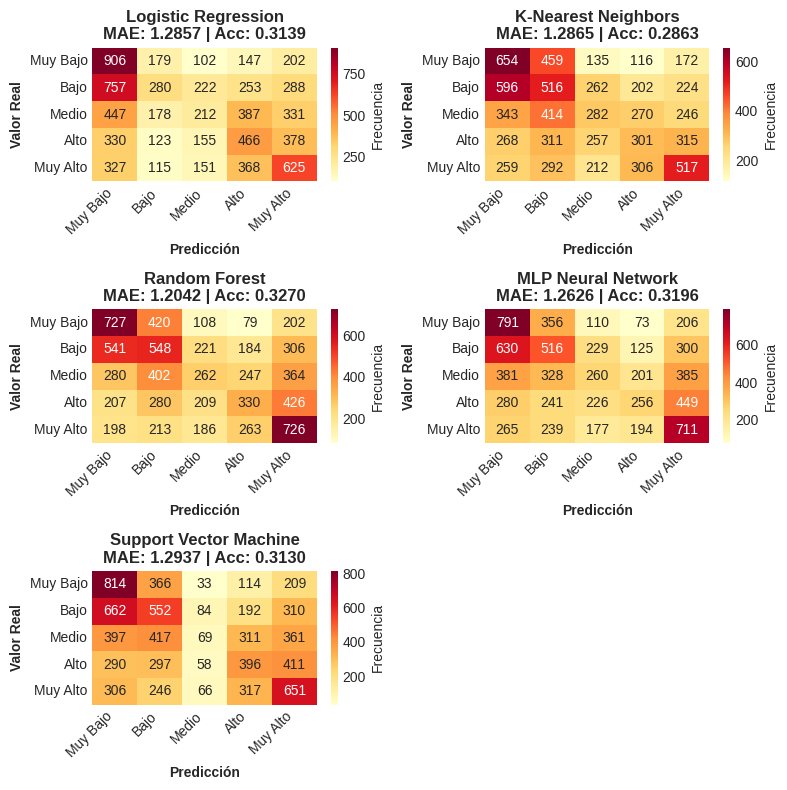

Matrices de confusión ordinales generadas
Guardadas en: matrices_confusion_ordinal.png


In [ ]:
# =============================================================================
# MATRICES DE CONFUSIÓN PARA REGRESIÓN ORDINAL
# =============================================================================
fig, axes = plt.subplots(3, 2, figsize=(8, 8))
axes = axes.ravel()

for idx, (model_name, results) in enumerate(results_ordinal.items()):
    if idx >= 6:
        break

    cm = confusion_matrix(y_test_ord, results['y_pred'])

    ax = axes[idx]
    sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrRd', ax=ax,
                cbar_kws={'label': 'Frecuencia'})
    ax.set_xlabel('Predicción', fontweight='bold')
    ax.set_ylabel('Valor Real', fontweight='bold')
    ax.set_title(f'{model_name}\nMAE: {results["mae"]:.4f} | Acc: {results["accuracy"]:.4f}',
                 fontweight='bold')
    ax.set_xticklabels(['Muy Bajo', 'Bajo', 'Medio', 'Alto', 'Muy Alto'],
                       rotation=45, ha='right')
    ax.set_yticklabels(['Muy Bajo', 'Bajo', 'Medio', 'Alto', 'Muy Alto'],
                       rotation=0)

# Ocultar subplots no usados
if len(results_ordinal) < 6:
    for idx in range(len(results_ordinal), 6):
        axes[idx].axis('off')

plt.tight_layout()
plt.savefig('matrices_confusion_ordinal.png', dpi=300, bbox_inches='tight')
plt.show()

print("Matrices de confusión ordinales generadas")
print("Guardadas en: matrices_confusion_ordinal.png")

##### C. Análisis de Errores - Regresión Ordinal

Análisis detallado de los errores de predicción en las categorías ordinales.

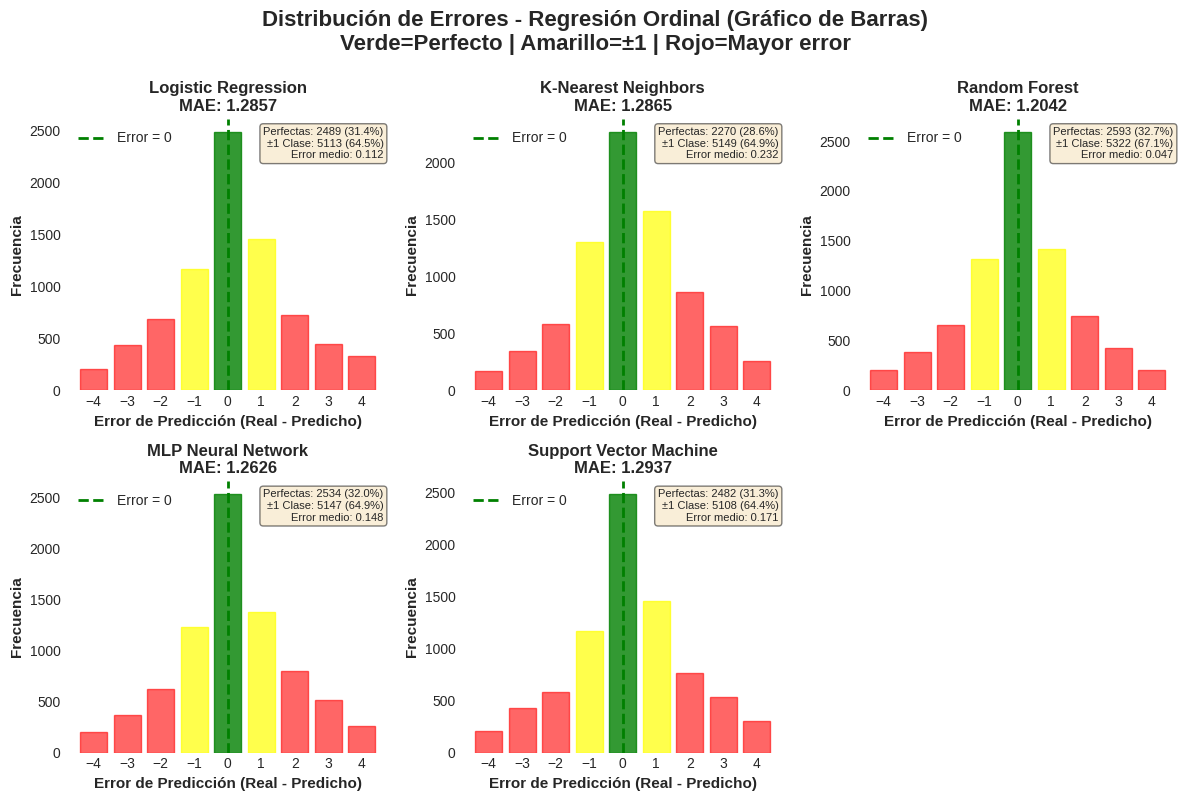


 ANÁLISIS DE ERRORES:
Error = 0 (Verde): Predicción perfecta
Error = ±1 (Amarillo): Predicción adyacente (aceptable en ordinal)
Error ≥ ±2 (Rojo): Predicción con error significativo
Distribución centrada en 0 = modelo bien calibrado


In [ ]:
# Gráfico de barras para análisis de errores por modelo ordinal
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

fig.patch.set_facecolor('white')
for ax in axes:
    ax.set_facecolor('white')

for idx, model_name in enumerate(results_ordinal.keys()):
    ax = axes[idx]

    y_pred = results_ordinal[model_name]['y_pred']
    errors = y_test_ord - y_pred  # Error = Real - Predicho

    # Rango completo de errores (asegura todas las columnas)
    error_range = range(-4, 5)  # -4 a +4
    error_counts = [np.sum(errors == e) for e in error_range]

    # Gráfico de barras
    bars = ax.bar(error_range, error_counts, edgecolor='black')

    # Colorear barras según la magnitud del error
    for i, e in enumerate(error_range):
        if e == 0:
            bars[i].set_color('green')
            bars[i].set_alpha(0.8)
        elif abs(e) == 1:
            bars[i].set_color('yellow')
            bars[i].set_alpha(0.7)
        else:
            bars[i].set_color('red')
            bars[i].set_alpha(0.6)

    # Línea vertical para el error 0
    ax.axvline(x=0, color='green', linestyle='--', linewidth=2, label='Error = 0')

    ax.set_xticks(error_range)
    ax.set_xlabel('Error de Predicción (Real - Predicho)', fontweight='bold', fontsize=11)
    ax.set_ylabel('Frecuencia', fontweight='bold', fontsize=11)
    ax.set_title(f'{model_name}\nMAE: {results_ordinal[model_name]["mae"]:.4f}',
                 fontweight='bold', fontsize=12)
    ax.grid(axis='y', alpha=0.3)
    ax.legend()

    # Estadísticas de error
    mae = results_ordinal[model_name]['mae']
    perfect = np.sum(errors == 0)
    adjacent = np.sum(np.abs(errors) <= 1)
    total = len(errors)

    text = f'Perfectas: {perfect} ({perfect/total*100:.1f}%)\n'
    text += f'±1 Clase: {adjacent} ({adjacent/total*100:.1f}%)\n'
    text += f'Error medio: {np.mean(errors):.3f}'

    ax.text(0.98, 0.97, text, transform=ax.transAxes,
            verticalalignment='top', horizontalalignment='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
            fontsize=8)

# Ocultar subplot extra (si hay menos de 6 modelos)
axes[-1].axis('off')

plt.suptitle('Distribución de Errores - Regresión Ordinal (Gráfico de Barras)\n'
             'Verde=Perfecto | Amarillo=±1 | Rojo=Mayor error',
             fontsize=16, fontweight='bold', y=0.995)
plt.tight_layout()
plt.show()

print("\n ANÁLISIS DE ERRORES:")
print("="*80)
print("Error = 0 (Verde): Predicción perfecta")
print("Error = ±1 (Amarillo): Predicción adyacente (aceptable en ordinal)")
print("Error ≥ ±2 (Rojo): Predicción con error significativo")
print("Distribución centrada en 0 = modelo bien calibrado")
print("="*80)


## 5. Reducción de Dimensión

En esta sección evaluamos diferentes técnicas de reducción de dimensión para establecer si es posible reducir la complejidad del modelo final sin sacrificar significativamente el rendimiento.

### 5.1 Análisis Individual de Variables

Realizamos un análisis de la capacidad discriminativa de cada característica mediante medidas de correlación y análisis de importancia.

In [ ]:
# 5.1.1 Correlación de Pearson con la variable objetivo
print("=" * 80)
print("5.1.1 ANÁLISIS DE CORRELACIÓN CON LA VARIABLE OBJETIVO")
print("=" * 80)

# Calcular correlaciones con la variable binaria
correlations = pd.DataFrame({
    'Feature': X_train.columns,
    'Correlation': [X_train[col].corr(y_train_class) for col in X_train.columns]
})
correlations['Abs_Correlation'] = correlations['Correlation'].abs()
correlations = correlations.sort_values('Abs_Correlation', ascending=False)

print(f"\n Top 20 variables con mayor correlación absoluta:")
print(correlations.head(20).to_string(index=False))

# Estadísticas de correlación
print(f"\n Estadísticas de correlación:")
print(f"   - Media: {correlations['Correlation'].mean():.4f}")
print(f"   - Mediana: {correlations['Correlation'].median():.4f}")
print(f"   - Máxima (absoluta): {correlations['Abs_Correlation'].max():.4f}")
print(f"   - Mínima (absoluta): {correlations['Abs_Correlation'].min():.4f}")

5.1.1 ANÁLISIS DE CORRELACIÓN CON LA VARIABLE OBJETIVO

 Top 20 variables con mayor correlación absoluta:
                      Feature  Correlation  Abs_Correlation
                   kw_avg_avg     0.164470         0.164470
                       LDA_02    -0.159687         0.159687
        data_channel_is_world    -0.155464         0.155464
                   is_weekend     0.137909         0.137909
data_channel_is_entertainment    -0.110560         0.110560
       data_channel_is_socmed     0.110324         0.110324
          weekday_is_saturday     0.103045         0.103045
         data_channel_is_tech     0.095064         0.095064
                   kw_min_avg     0.093291         0.093291
                    num_hrefs     0.088052         0.088052
                       LDA_04     0.086424         0.086424
            weekday_is_sunday     0.085490         0.085490
                   kw_max_avg     0.079455         0.079455
                       LDA_01    -0.074055         0.0

In [ ]:
# 5.1.2 Análisis de Varianza (ANOVA F-statistic)
from sklearn.feature_selection import f_classif

print("\n" + "=" * 80)
print("5.1.2 ANÁLISIS DE VARIANZA (F-STATISTIC)")
print("=" * 80)

# Calcular F-statistic para cada variable
f_scores, p_values = f_classif(X_train, y_train_class)

f_analysis = pd.DataFrame({
    'Feature': X_train.columns,
    'F_Score': f_scores,
    'P_Value': p_values
})
f_analysis['Significant'] = f_analysis['P_Value'] < 0.05
f_analysis = f_analysis.sort_values('F_Score', ascending=False)

print(f"\n Resumen estadístico:")
print(f"   • Variables significativas (p < 0.05): {f_analysis['Significant'].sum()} de {len(f_analysis)}")
print(f"   • Porcentaje: {(f_analysis['Significant'].sum() / len(f_analysis)) * 100:.1f}%")


5.1.2 ANÁLISIS DE VARIANZA (F-STATISTIC)

 Resumen estadístico:
   • Variables significativas (p < 0.05): 47 de 58
   • Porcentaje: 81.0%


posiblemente cambias por menos importantes de los mejores modelos

In [ ]:
# 5.1.3 Identificación de características candidatas a eliminación
print("\n" + "=" * 80)
print("5.1.3 IDENTIFICACIÓN DE CARACTERÍSTICAS CANDIDATAS A ELIMINACIÓN")
print("=" * 80)

# Criterios para eliminación
low_correlation_threshold = 0.01  # Correlación absoluta muy baja
low_f_score_threshold = 1.0       # F-score muy bajo
high_p_value_threshold = 0.1      # No significativo

# Identificar candidatos
weak_features = f_analysis[
    (f_analysis['F_Score'] < low_f_score_threshold) |
    (f_analysis['P_Value'] > high_p_value_threshold)
].copy()

weak_features = weak_features.merge(
    correlations[['Feature', 'Abs_Correlation']],
    on='Feature'
)

weak_features['Reason'] = weak_features.apply(
    lambda row: 'Baja correlación + No significativo' if row['Abs_Correlation'] < low_correlation_threshold and row['P_Value'] > high_p_value_threshold
    else 'No significativo (p > 0.1)' if row['P_Value'] > high_p_value_threshold
    else 'F-score muy bajo', axis=1
)

print(f"\n  Características candidatas a eliminación: {len(weak_features)}")
print(f"\n Criterios utilizados:")
print(f"    Correlación absoluta < {low_correlation_threshold}")
print(f"    F-Score < {low_f_score_threshold}")
print(f"    P-Value > {high_p_value_threshold}")

if len(weak_features) > 0:
    # Guardar lista de características débiles
    weak_feature_names = weak_features['Feature'].tolist()
else:
    print("\n✓ No se identificaron características débiles con los criterios establecidos")
    weak_feature_names = []

print(f"\n CONCLUSIÓN:")
print(f"    Total de variables: {len(X_train.columns)}")
print(f"    Candidatas a eliminar: {len(weak_feature_names)} ({len(weak_feature_names)/len(X_train.columns)*100:.1f}%)")
print(f"    Variables a retener: {len(X_train.columns) - len(weak_feature_names)} ({(len(X_train.columns) - len(weak_feature_names))/len(X_train.columns)*100:.1f}%)")


5.1.3 IDENTIFICACIÓN DE CARACTERÍSTICAS CANDIDATAS A ELIMINACIÓN

  Características candidatas a eliminación: 10

 Criterios utilizados:
    Correlación absoluta < 0.01
    F-Score < 1.0
    P-Value > 0.1

 CONCLUSIÓN:
    Total de variables: 58
    Candidatas a eliminar: 10 (17.2%)
    Variables a retener: 48 (82.8%)


### 5.2 Extracción de Características Lineal (PCA)

Aplicamos PCA para reducir la dimensionalidad y evaluamos los 2 mejores modelos de la Sección 4.

In [ ]:
# 5.2.1 Análisis de varianza explicada para determinar número de componentes
from sklearn.decomposition import PCA

print("=" * 80)
print("5.2.1 ANÁLISIS PCA - DETERMINACIÓN DEL NÚMERO DE COMPONENTES")
print("=" * 80)

# PCA con todos los componentes para análisis
pca_full = PCA(random_state=16)
pca_full.fit(X_train_scaled)

# Análisis de varianza explicada
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Encontrar número de componentes para diferentes niveles de varianza
variance_thresholds = [0.80, 0.85, 0.90, 0.95, 0.99]
n_components_dict = {}

for threshold in variance_thresholds:
    n_comp = np.argmax(cumulative_variance >= threshold) + 1
    n_components_dict[threshold] = n_comp
    print(f"    {threshold*100:.0f}% varianza explicada: {n_comp} componentes ({n_comp/len(X_train.columns)*100:.1f}% del total)")

# Criterio seleccionado: 90% de varianza explicada (balance entre reducción y rendimiento)
selected_n_components = n_components_dict[0.90]
reduction_percentage = (1 - selected_n_components / len(X_train.columns)) * 100

print(f"\n CRITERIO SELECCIONADO: 90% de varianza explicada")
print(f"   Componentes: {selected_n_components} de {len(X_train.columns)} originales")
print(f"   Reducción de dimensionalidad: {reduction_percentage:.1f}%")
print(f"\n JUSTIFICACIÓN:")
print(f"   El umbral de 90% es un balance estándar que retiene información suficiente")
print(f"   para capturar los patrones principales sin incluir ruido excesivo.")

5.2.1 ANÁLISIS PCA - DETERMINACIÓN DEL NÚMERO DE COMPONENTES
    80% varianza explicada: 23 componentes (39.7% del total)
    85% varianza explicada: 26 componentes (44.8% del total)
    90% varianza explicada: 30 componentes (51.7% del total)
    95% varianza explicada: 36 componentes (62.1% del total)
    99% varianza explicada: 45 componentes (77.6% del total)

 CRITERIO SELECCIONADO: 90% de varianza explicada
   Componentes: 30 de 58 originales
   Reducción de dimensionalidad: 48.3%

 JUSTIFICACIÓN:
   El umbral de 90% es un balance estándar que retiene información suficiente
   para capturar los patrones principales sin incluir ruido excesivo.


In [ ]:
# 5.2.2 Aplicar PCA y transformar datos
print("\n" + "=" * 80)
print("5.2.2 TRANSFORMACIÓN DE DATOS CON PCA")
print("=" * 80)

# Aplicar PCA con el número de componentes seleccionado
pca = PCA(n_components=selected_n_components, random_state=16)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print(f"\n Datos transformados con {selected_n_components} componentes principales")
print(f"    Forma original: {X_train_scaled.shape}")
print(f"    Forma PCA: {X_train_pca.shape}")
print(f"    Varianza total explicada: {pca.explained_variance_ratio_.sum()*100:.2f}%")
print(f"    Reducción de dimensionalidad: {reduction_percentage:.1f}%")


5.2.2 TRANSFORMACIÓN DE DATOS CON PCA

 Datos transformados con 30 componentes principales
    Forma original: (31715, 58)
    Forma PCA: (31715, 30)
    Varianza total explicada: 90.21%
    Reducción de dimensionalidad: 48.3%


In [ ]:
# 5.2.3 Identificar los 2 mejores modelos de la Sección 4
print("\n" + "=" * 80)
print("5.2.3 SELECCIÓN DE LOS 2 MEJORES MODELOS DE LA SECCIÓN 4")
print("=" * 80)

# Ordenar modelos por F1-Score en test (clasificación binaria)
model_performance = []
for model_name, metrics in results_classification.items():
    model_performance.append({
        'Model': model_name,
        'F1_Score': metrics['test_f1'],
        'ROC_AUC': metrics.get('test_roc_auc', 0)
    })

performance_df = pd.DataFrame(model_performance).sort_values('F1_Score', ascending=False)

# Seleccionar los 2 mejores
top_2_models = performance_df.head(2)['Model'].tolist()

print(f"\n Top 2 modelos seleccionados para evaluación con PCA:")
for i, (idx, row) in enumerate(top_2_models_df := performance_df.head(2).iterrows(), 1):
    print(f"   {i}. {row['Model']}")
    print(f"      - F1-Score (original): {row['F1_Score']:.4f}")
    print(f"      - ROC-AUC (original): {row['ROC_AUC']:.4f}")

print(f"\n Estos modelos serán re-entrenados usando {selected_n_components} componentes PCA")


5.2.3 SELECCIÓN DE LOS 2 MEJORES MODELOS DE LA SECCIÓN 4

 Top 2 modelos seleccionados para evaluación con PCA:
   1. Random Forest
      - F1-Score (original): 0.6601
      - ROC-AUC (original): 0.7257
   2. Logistic Regression
      - F1-Score (original): 0.6507
      - ROC-AUC (original): 0.6988

 Estos modelos serán re-entrenados usando 30 componentes PCA


In [ ]:
# 5.2.4 Re-entrenar los 2 mejores modelos con PCA
print("\n" + "=" * 80)
print("5.2.4 RE-ENTRENAMIENTO DE MODELOS CON PCA")
print("=" * 80)

# Mapear nombres a modelos e hiperparámetros
model_mapping = {
    'Logistic Regression': (LogisticRegression, results_classification['Logistic Regression']['best_params']),
    'K-Nearest Neighbors': (KNeighborsClassifier, results_classification['K-Nearest Neighbors']['best_params']),
    'Random Forest': (RandomForestClassifier, results_classification['Random Forest']['best_params']),
    'MLP Neural Network': (MLPClassifier, results_classification['MLP Neural Network']['best_params']),
    'Support Vector Machine': (SVC, results_classification['Support Vector Machine']['best_params'])
}

# Guardar resultados originales para comparación posterior
results_original = {}
for model_name in top_2_models:
    # Re-entrenar con datos originales para obtener tiempos comparables
    ModelClass, best_params = model_mapping[model_name]
    model_orig = ModelClass(**best_params)

    start_time = time.time()
    model_orig.fit(X_train_scaled, y_train_class)
    train_time = time.time() - start_time

    y_pred_orig = model_orig.predict(X_test_scaled)
    f1_orig = f1_score(y_test_class, y_pred_orig, average='weighted')
    accuracy_orig = accuracy_score(y_test_class, y_pred_orig)

    if hasattr(model_orig, 'predict_proba'):
        y_proba_orig = model_orig.predict_proba(X_test_scaled)[:, 1]
        roc_auc_orig = roc_auc_score(y_test_class, y_proba_orig)
    elif hasattr(model_orig, 'decision_function'):
        y_score_orig = model_orig.decision_function(X_test_scaled)
        roc_auc_orig = roc_auc_score(y_test_class, y_score_orig)
    else:
        roc_auc_orig = None

    results_original[model_name] = {
        'f1_score': f1_orig,
        'accuracy': accuracy_orig,
        'roc_auc': roc_auc_orig,
        'train_time': train_time
    }

print(f"\n✓ Métricas originales guardadas para comparación")

results_pca = {}

for model_name in top_2_models:
    print(f"\n{'='*60}")
    print(f"Entrenando: {model_name} con PCA")
    print(f"{'='*60}")

    # Obtener modelo y parámetros
    ModelClass, best_params = model_mapping[model_name]

    # Crear modelo con mejores hiperparámetros
    model_pca = ModelClass(**best_params)

    # Entrenar
    start_time = time.time()
    model_pca.fit(X_train_pca, y_train_class)
    train_time = time.time() - start_time

    # Predicciones
    y_pred_pca = model_pca.predict(X_test_pca)

    # Métricas
    f1_pca = f1_score(y_test_class, y_pred_pca, average='weighted')
    accuracy_pca = accuracy_score(y_test_class, y_pred_pca)

    # ROC-AUC (si el modelo tiene predict_proba)
    if hasattr(model_pca, 'predict_proba'):
        y_proba_pca = model_pca.predict_proba(X_test_pca)[:, 1]
        roc_auc_pca = roc_auc_score(y_test_class, y_proba_pca)
    elif hasattr(model_pca, 'decision_function'):
        y_score_pca = model_pca.decision_function(X_test_pca)
        roc_auc_pca = roc_auc_score(y_test_class, y_score_pca)
    else:
        roc_auc_pca = None

    # Guardar resultados
    results_pca[model_name] = {
        'f1_score': f1_pca,
        'accuracy': accuracy_pca,
        'roc_auc': roc_auc_pca,
        'train_time': train_time
    }

    print(f"    F1-Score: {f1_pca:.4f}")
    print(f"    Accuracy: {accuracy_pca:.4f}")
    if roc_auc_pca:
        print(f"    ROC-AUC: {roc_auc_pca:.4f}")
    print(f"    Tiempo de entrenamiento: {train_time:.2f}s")

print(f"\n{'='*80}")
print("✓ Entrenamiento con PCA completado")
print(f"{'='*80}")


5.2.4 RE-ENTRENAMIENTO DE MODELOS CON PCA

✓ Métricas originales guardadas para comparación

Entrenando: Random Forest con PCA
    F1-Score: 0.6462
    Accuracy: 0.6462
    ROC-AUC: 0.7002
    Tiempo de entrenamiento: 68.65s

Entrenando: Logistic Regression con PCA
    F1-Score: 0.6365
    Accuracy: 0.6368
    ROC-AUC: 0.6820
    Tiempo de entrenamiento: 0.13s

✓ Entrenamiento con PCA completado


In [ ]:
# 5.2.5 Comparación de resultados: Original vs PCA
print("\n" + "=" * 80)
print("5.2.5 COMPARACIÓN: DATOS ORIGINALES VS PCA")
print("=" * 80)

# Crear tabla comparativa
comparison_pca = []
for model_name in top_2_models:
    # Resultados originales
    original = results_classification[model_name]
    # Resultados PCA
    pca_res = results_pca[model_name]

    comparison_pca.append({
        'Modelo': model_name,
        'F1_Original': original['test_f1'],
        'F1_PCA': pca_res['f1_score'],
        'Δ_F1': pca_res['f1_score'] - original['test_f1'],
        'ROC_Original': original.get('test_roc_auc', None),
        'ROC_PCA': pca_res['roc_auc'],
        'Δ_ROC': (pca_res['roc_auc'] - original['test_roc_auc']) if pca_res['roc_auc'] and original.get('test_roc_auc') else None,
        'Reducción_%': reduction_percentage
    })

comparison_pca_df = pd.DataFrame(comparison_pca)

print(f"\n Tabla Comparativa:")
print(comparison_pca_df.to_string(index=False))

print(f"\n ANÁLISIS:")
for _, row in comparison_pca_df.iterrows():
    print(f"\n   - {row['Modelo']}:")
    print(f"     - Reducción de dimensionalidad: {row['Reducción_%']:.1f}%")
    print(f"     - Cambio en F1-Score: {row['Δ_F1']:+.4f} ({row['Δ_F1']/row['F1_Original']*100:+.2f}%)")
    if row['Δ_ROC'] is not None:
        print(f"     - Cambio en ROC-AUC: {row['Δ_ROC']:+.4f} ({row['Δ_ROC']/row['ROC_Original']*100:+.2f}%)")


5.2.5 COMPARACIÓN: DATOS ORIGINALES VS PCA

 Tabla Comparativa:
             Modelo  F1_Original   F1_PCA      Δ_F1  ROC_Original  ROC_PCA     Δ_ROC  Reducción_%
      Random Forest     0.660121 0.646162 -0.013959      0.725680 0.700198 -0.025482    48.275862
Logistic Regression     0.650731 0.636521 -0.014210      0.698794 0.682000 -0.016795    48.275862

 ANÁLISIS:

   - Random Forest:
     - Reducción de dimensionalidad: 48.3%
     - Cambio en F1-Score: -0.0140 (-2.11%)
     - Cambio en ROC-AUC: -0.0255 (-3.51%)

   - Logistic Regression:
     - Reducción de dimensionalidad: 48.3%
     - Cambio en F1-Score: -0.0142 (-2.18%)
     - Cambio en ROC-AUC: -0.0168 (-2.40%)


### 5.3 Extracción de Características No Lineal (UMAP)

Aplicamos UMAP para reducción de dimensionalidad no lineal y evaluamos los 2 mejores modelos.

In [ ]:
# Instalación de UMAP (si es necesario)
try:
    import umap
    print(" UMAP ya está instalado")
except ImportError:
    print(" Instalando UMAP...")
    !pip install umap-learn --quiet
    import umap
    print(" UMAP instalado correctamente")

 UMAP ya está instalado


In [ ]:
# 5.3.1 Determinación del número de componentes para UMAP
print("=" * 80)
print("5.3.1 DETERMINACIÓN DEL NÚMERO DE COMPONENTES UMAP")
print("=" * 80)

# Criterio: Usar el mismo número de componentes que PCA para comparación justa
# Alternativamente, se puede usar un análisis de reconstrucción o validación cruzada
umap_n_components = selected_n_components

print(f"\n CRITERIO SELECCIONADO: {umap_n_components} componentes")
print(f"\n JUSTIFICACIÓN:")
print(f"    Se usa el mismo número de componentes que PCA ({umap_n_components})")
print(f"    Esto permite una comparación directa entre métodos lineales (PCA) y no lineales (UMAP)")
print(f"    Reducción de dimensionalidad: {reduction_percentage:.1f}%")
print(f"    UMAP puede capturar relaciones no lineales que PCA no detecta")

print(f"\n Parámetros de UMAP:")
print(f"    n_components: {umap_n_components}")
print(f"    n_neighbors: 15 (valor por defecto, balance entre local/global)")
print(f"    min_dist: 0.1 (valor por defecto, distribución de puntos)")
print(f"    metric: 'euclidean' (distancia estándar)")
print(f"    random_state: 16 (reproducibilidad)")

5.3.1 DETERMINACIÓN DEL NÚMERO DE COMPONENTES UMAP

 CRITERIO SELECCIONADO: 30 componentes

 JUSTIFICACIÓN:
    Se usa el mismo número de componentes que PCA (30)
    Esto permite una comparación directa entre métodos lineales (PCA) y no lineales (UMAP)
    Reducción de dimensionalidad: 48.3%
    UMAP puede capturar relaciones no lineales que PCA no detecta

 Parámetros de UMAP:
    n_components: 30
    n_neighbors: 15 (valor por defecto, balance entre local/global)
    min_dist: 0.1 (valor por defecto, distribución de puntos)
    metric: 'euclidean' (distancia estándar)
    random_state: 16 (reproducibilidad)


In [ ]:
# 5.3.2 Aplicar UMAP y transformar datos
print("\n" + "=" * 80)
print("5.3.2 TRANSFORMACIÓN DE DATOS CON UMAP")
print("=" * 80)

# Aplicar UMAP
print("\n Aplicando UMAP (puede tomar varios minutos)...")
start_time = time.time()

umap_reducer = umap.UMAP(
    n_components=umap_n_components,
    n_neighbors=15,
    min_dist=0.1,
    metric='euclidean',
    random_state=16,
    verbose=False
)

X_train_umap = umap_reducer.fit_transform(X_train_scaled)
X_test_umap = umap_reducer.transform(X_test_scaled)

umap_time = time.time() - start_time

print(f"\n Transformación UMAP completada en {umap_time:.2f} segundos")
print(f"    Forma original: {X_train_scaled.shape}")
print(f"    Forma UMAP: {X_train_umap.shape}")
print(f"    Reducción de dimensionalidad: {reduction_percentage:.1f}%")


5.3.2 TRANSFORMACIÓN DE DATOS CON UMAP

 Aplicando UMAP (puede tomar varios minutos)...

 Transformación UMAP completada en 128.24 segundos
    Forma original: (31715, 58)
    Forma UMAP: (31715, 30)
    Reducción de dimensionalidad: 48.3%


In [ ]:
# 5.3.3 Re-entrenar los 2 mejores modelos con UMAP
print("\n" + "=" * 80)
print("5.3.3 RE-ENTRENAMIENTO DE MODELOS CON UMAP")
print("=" * 80)

results_umap = {}

for model_name in top_2_models:
    print(f"\n{'='*60}")
    print(f"Entrenando: {model_name} con UMAP")
    print(f"{'='*60}")

    # Obtener modelo y parámetros
    ModelClass, best_params = model_mapping[model_name]

    # Crear modelo con mejores hiperparámetros
    model_umap = ModelClass(**best_params)

    # Entrenar
    start_time = time.time()
    model_umap.fit(X_train_umap, y_train_class)
    train_time = time.time() - start_time

    # Predicciones
    y_pred_umap = model_umap.predict(X_test_umap)

    # Métricas
    f1_umap = f1_score(y_test_class, y_pred_umap, average='weighted')
    accuracy_umap = accuracy_score(y_test_class, y_pred_umap)

    # ROC-AUC
    if hasattr(model_umap, 'predict_proba'):
        y_proba_umap = model_umap.predict_proba(X_test_umap)[:, 1]
        roc_auc_umap = roc_auc_score(y_test_class, y_proba_umap)
    elif hasattr(model_umap, 'decision_function'):
        y_score_umap = model_umap.decision_function(X_test_umap)
        roc_auc_umap = roc_auc_score(y_test_class, y_score_umap)
    else:
        roc_auc_umap = None

    # Guardar resultados
    results_umap[model_name] = {
        'f1_score': f1_umap,
        'accuracy': accuracy_umap,
        'roc_auc': roc_auc_umap,
        'train_time': train_time
    }

    print(f"   - F1-Score: {f1_umap:.4f}")
    print(f"   - Accuracy: {accuracy_umap:.4f}")
    if roc_auc_umap:
        print(f"   - ROC-AUC: {roc_auc_umap:.4f}")
    print(f"   - Tiempo de entrenamiento: {train_time:.2f}s")

print(f"\n{'='*80}")
print("- Entrenamiento con UMAP completado")
print(f"{'='*80}")


5.3.3 RE-ENTRENAMIENTO DE MODELOS CON UMAP

Entrenando: Random Forest con UMAP
   - F1-Score: 0.6115
   - Accuracy: 0.6118
   - ROC-AUC: 0.6513
   - Tiempo de entrenamiento: 94.66s

Entrenando: Logistic Regression con UMAP
   - F1-Score: 0.5817
   - Accuracy: 0.5865
   - ROC-AUC: 0.6282
   - Tiempo de entrenamiento: 1.67s

- Entrenamiento con UMAP completado


In [ ]:
# 5.3.4 Comparación: Original vs PCA vs UMAP
print("\n" + "=" * 80)
print("5.3.4 COMPARACIÓN FINAL: ORIGINAL vs PCA vs UMAP")
print("=" * 80)

# Crear DataFrame comparativo
comparison_data = []

for model_name in top_2_models:
    # Datos originales
    orig = results_original[model_name]
    comparison_data.append({
        'Modelo': model_name,
        'Método': 'Original',
        'Features': X_train_scaled.shape[1],
        'F1-Score': orig['f1_score'],
        'Accuracy': orig['accuracy'],
        'ROC-AUC': orig['roc_auc'] if orig['roc_auc'] else 'N/A',
        'Tiempo (s)': orig['train_time']
    })

    # Datos PCA
    pca_res = results_pca[model_name]
    comparison_data.append({
        'Modelo': model_name,
        'Método': 'PCA',
        'Features': selected_n_components,
        'F1-Score': pca_res['f1_score'],
        'Accuracy': pca_res['accuracy'],
        'ROC-AUC': pca_res['roc_auc'] if pca_res['roc_auc'] else 'N/A',
        'Tiempo (s)': pca_res['train_time']
    })

    # Datos UMAP
    umap_res = results_umap[model_name]
    comparison_data.append({
        'Modelo': model_name,
        'Método': 'UMAP',
        'Features': selected_n_components,
        'F1-Score': umap_res['f1_score'],
        'Accuracy': umap_res['accuracy'],
        'ROC-AUC': umap_res['roc_auc'] if umap_res['roc_auc'] else 'N/A',
        'Tiempo (s)': umap_res['train_time']
    })

comparacion_final = pd.DataFrame(comparison_data)
print("\nTabla comparativa completa:")
print(comparacion_final.to_string(index=False))

# Análisis de mejora/degradación
print("\n" + "=" * 80)
print("ANÁLISIS DE IMPACTO POR MODELO")
print("=" * 80)

for model_name in top_2_models:
    print(f"\n{model_name}:")
    model_data = comparacion_final[comparacion_final['Modelo'] == model_name]

    orig_f1 = model_data[model_data['Método'] == 'Original']['F1-Score'].values[0]
    pca_f1 = model_data[model_data['Método'] == 'PCA']['F1-Score'].values[0]
    umap_f1 = model_data[model_data['Método'] == 'UMAP']['F1-Score'].values[0]

    pca_change = ((pca_f1 - orig_f1) / orig_f1) * 100
    umap_change = ((umap_f1 - orig_f1) / orig_f1) * 100

    print(f"  - Reducción de features: {X_train_scaled.shape[1]} → {selected_n_components} ({selected_n_components/X_train_scaled.shape[1]*100:.1f}%)")
    print(f"  - PCA: {pca_change:+.2f}% cambio en F1-Score")
    print(f"  - UMAP: {umap_change:+.2f}% cambio en F1-Score")

    if abs(pca_change) < 1:
        print(f"   PCA mantiene rendimiento similar con menos features")
    elif pca_change > 0:
        print(f"   PCA mejora el rendimiento")
    else:
        print(f"   PCA reduce ligeramente el rendimiento")

    if abs(umap_change) < 1:
        print(f"   UMAP mantiene rendimiento similar con menos features")
    elif umap_change > 0:
        print(f"   UMAP mejora el rendimiento")
    else:
        print(f"   UMAP reduce ligeramente el rendimiento")


5.3.4 COMPARACIÓN FINAL: ORIGINAL vs PCA vs UMAP

Tabla comparativa completa:
             Modelo   Método  Features  F1-Score  Accuracy  ROC-AUC  Tiempo (s)
      Random Forest Original        58  0.658471  0.658469 0.725572   43.589754
      Random Forest      PCA        30  0.646162  0.646235 0.700198   68.654744
      Random Forest     UMAP        30  0.611452  0.611805 0.651333   94.660955
Logistic Regression Original        58  0.651353  0.651532 0.698755    0.435890
Logistic Regression      PCA        30  0.636521  0.636776 0.682000    0.125660
Logistic Regression     UMAP        30  0.581710  0.586455 0.628161    1.665988

ANÁLISIS DE IMPACTO POR MODELO

Random Forest:
  - Reducción de features: 58 → 30 (51.7%)
  - PCA: -1.87% cambio en F1-Score
  - UMAP: -7.14% cambio en F1-Score
   PCA reduce ligeramente el rendimiento
   UMAP reduce ligeramente el rendimiento

Logistic Regression:
  - Reducción de features: 58 → 30 (51.7%)
  - PCA: -2.28% cambio en F1-Score
  - UMAP: -10.69